# Import libraries and data upload

In [321]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import LabelEncoder
import math
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
import xgboost as xgb
import shap
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_validate, GridSearchCV, cross_validate
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import learning_curve
from scipy.stats import zscore
import pprint
import joblib

In [253]:
train_df = pd.read_csv(r'C:\Users\USER\OneDrive\Documents\Property_prices_predictions\train.csv')
test_df = pd.read_csv(r'C:\Users\USER\OneDrive\Documents\Property_prices_predictions\test.csv')
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Data cleaning

In [254]:
print(train_df.shape)
print(test_df.shape)

(1460, 81)
(1459, 80)


In [255]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [256]:
train_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [257]:
test_df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [258]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


The dataset contains 1,460 residential property records and 81 features describing physical attributes, quality ratings, amenities, and location characteristics, along with the final sale price. There is a mix of numerical variables and categorical variables. A noticeable portion of the missing data is concentrated in features related to optional property elements such as basements, garages, masonry veneer, pools, and fences. This pattern indicates that the missingness is largely structural rather than random data loss. The descriptive statistics also show substantial variation in square footage and overall quality ratings, suggesting that the dataset captures a wide range of housing market segments—from small, lower-quality properties to large, high-end homes. This variation is essential for distinguishing price drivers in subsequent analysis.

### Missigness

In [259]:
# Missing value summary
missing_summary = (
    train_df.isnull().sum()
    .to_frame("Missing_Values")
    .assign(Percent=lambda df: 100 * df["Missing_Values"] / len(train_df))
    .query("Missing_Values > 0")
    .sort_values("Missing_Values", ascending=False)
)

missing_summary

,Missing_Values,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [260]:
missing_summary = (
    test_df.isnull().sum()
    .to_frame("Missing_Values")
    .assign(Percent=lambda df: 100 * df["Missing_Values"] / len(test_df))
    .query("Missing_Values > 0")
    .sort_values("Missing_Values", ascending=False)
)

missing_summary

,Missing_Values,Percent
PoolQC,1456,99.794380
MiscFeature,1408,96.504455
Alley,1352,92.666210
Fence,1169,80.123372
MasVnrType,894,61.274846
FireplaceQu,730,50.034270
LotFrontage,227,15.558602
GarageQual,78,5.346127
GarageCond,78,5.346127
GarageYrBlt,78,5.346127


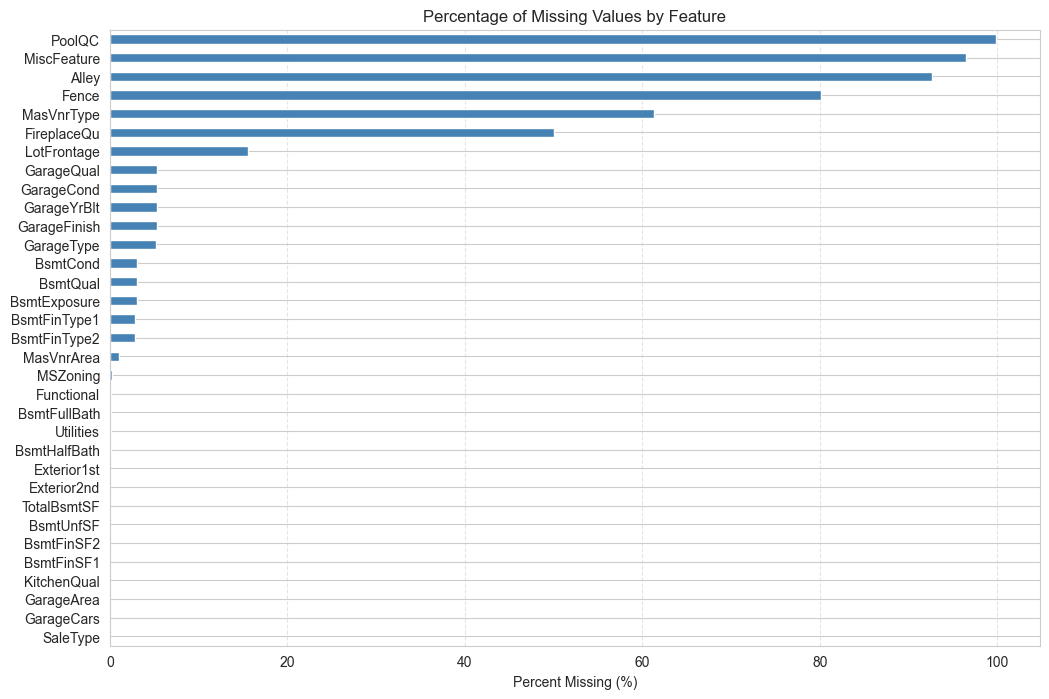

In [261]:
# missingness plot
plt.figure(figsize=(12, 8))
missing_summary["Percent"].plot(kind='barh', color='steelblue')
plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Percent Missing (%)")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [262]:
train = train_df.copy()
test = test_df.copy()

# Categorical: NA means feature does not exist
absence_cat = [
    'PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
    'GarageType','GarageFinish','GarageQual','GarageCond',
    'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
    'MasVnrType'
]

# Numeric: 0 means feature absent
absence_num = [
    'MasVnrArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
    'GarageArea','GarageCars'
]

# Small-missing categorical → mode
fill_mode_cols = [
    'Electrical','MSZoning','Utilities','SaleType',
    'Exterior1st','Exterior2nd','Functional'
]

# Small-missing numeric → median
fill_median_cols = ['GarageYrBlt']

for col in absence_cat:
    if col in train:
        train[col] = train[col].fillna("None")
    if col in test:
        test[col] = test[col].fillna("None")

for col in absence_num:
    if col in train:
        train[col] = train[col].fillna(0)
    if col in test:
        test[col] = test[col].fillna(0)

# Masonry
if "MasVnrType" in train.columns and "MasVnrArea" in train.columns:
    non_none_mask = train["MasVnrType"] != "None"
    if non_none_mask.any():
        mas_med = train.loc[non_none_mask, "MasVnrArea"].median()
        if np.isnan(mas_med):
            mas_med = 0.0
    else:
        mas_med = 0.0

    train.loc[train["MasVnrType"] == "None", "MasVnrArea"] = 0
    train["MasVnrArea"] = train["MasVnrArea"].fillna(mas_med)

    if "MasVnrType" in test.columns and "MasVnrArea" in test.columns:
        test.loc[test["MasVnrType"] == "None", "MasVnrArea"] = 0
        test["MasVnrArea"] = test["MasVnrArea"].fillna(mas_med)

# Basement
bsmt_num = ['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
            'BsmtFullBath','BsmtHalfBath']
for col in bsmt_num:
    if col in train.columns:
        train[col] = train[col].fillna(0)
    if col in test.columns:
        test[col] = test[col].fillna(0)

# Garage
gnum = ['GarageArea','GarageCars','GarageYrBlt']
if 'GarageType' in train.columns:
    for col in gnum:
        if col in train.columns:
            train[col] = train[col].where(train['GarageType'] != "None", 0)
            train[col] = train[col].fillna(0)
if 'GarageType' in test.columns:
    for col in gnum:
        if col in test.columns:
            test[col] = test[col].where(test['GarageType'] != "None", 0)
            test[col] = test[col].fillna(0)
else:
    for col in gnum:
        if col in test.columns:
            test[col] = test[col].fillna(0)

# LotFrontage — neighborhood median
if "LotFrontage" in train.columns and "Neighborhood" in train.columns:
    neigh_med = train.groupby("Neighborhood")["LotFrontage"].median()
    global_med = train["LotFrontage"].median()

    train["LotFrontage"] = train["LotFrontage"].fillna(train["Neighborhood"].map(neigh_med))
    train["LotFrontage"] = train["LotFrontage"].fillna(global_med)

    if "Neighborhood" in test.columns:
        test["LotFrontage"] = test["LotFrontage"].fillna(test["Neighborhood"].map(neigh_med))
        test["LotFrontage"] = test["LotFrontage"].fillna(global_med)

for col in fill_mode_cols:
    if col in train.columns:
        mode_val = train[col].mode(dropna=True)
        mode_val = mode_val.iloc[0] if len(mode_val) > 0 else "Missing"
        train[col] = train[col].fillna(mode_val)
        if col in test.columns:
            test[col] = test[col].fillna(mode_val)

for col in fill_median_cols:
    if col in train.columns:
        med = train[col].median()
        train[col] = train[col].fillna(med)
        if col in test.columns:
            test[col] = test[col].fillna(med)

num_cols = train.select_dtypes(include=['number']).columns
global_meds = train[num_cols].median()
for col in num_cols:
    train[col] = train[col].fillna(global_meds[col])
    if col in test.columns:
        test[col] = test[col].fillna(global_meds[col])

cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    train[col] = train[col].fillna("Missing")
    if col in test.columns:
        test[col] = test[col].fillna("Missing")

print("Train remaining NAs (total):", train.isna().sum().sum())
print("Test remaining NAs (total):", test.isna().sum().sum())

Train remaining NAs (total): 0
Test remaining NAs (total): 0


For missing data, I treated features based on what the absence actually represents. Categorical features where a missing value means the feature does not exist were filled with "None". Numerical features that represent physical measurements were filled with 0 when the corresponding feature was absent. For LotFrontage, I used the median LotFrontage within each Neighborhood. Features with only a few missing values (e.g., Electrical, MSZoning, Functional, SaleType) were filled using the mode, while numerical columns with occasional gaps (e.g., GarageYrBlt) were filled using the median. Any remaining numeric NaNs were filled with the overall median, and remaining categorical NaNs with "Missing" to ensure no missing values remained in either train or test data.

## Duplicates

In [263]:
train.duplicated().sum()

np.int64(0)

There are no duplicate values in the dataset.

# EDA

## Univeriate

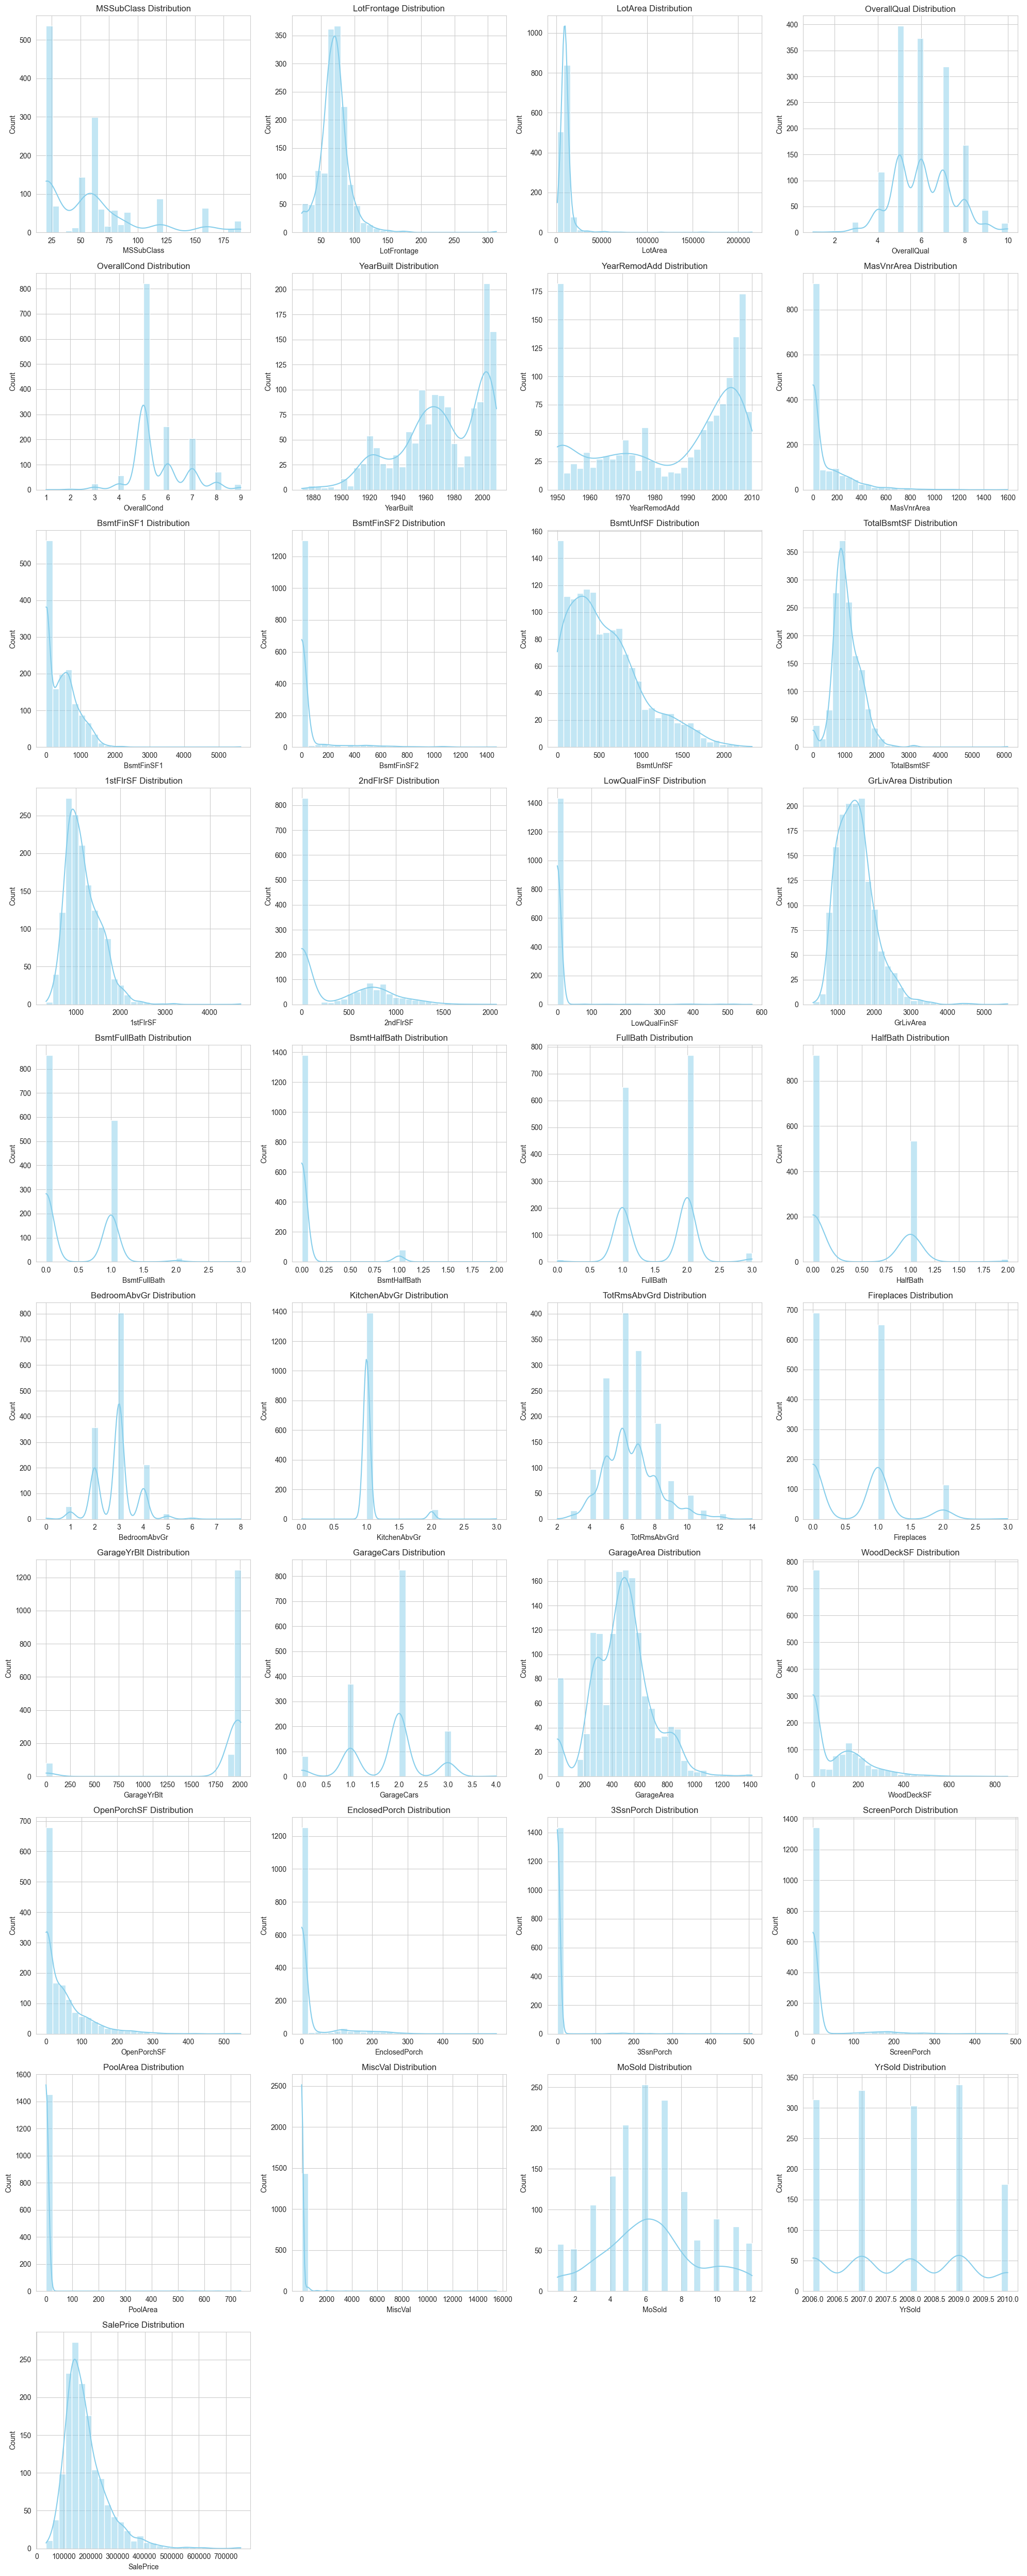

In [264]:
# numeric columns distribution
num_cols = train.select_dtypes(include=np.number).columns.tolist()
if 'Id' in num_cols:
    num_cols.remove('Id')

cols_per_row = 4
num_plots = len(num_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.histplot(train[col].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f'{col} Distribution')
    plt.tight_layout()

plt.show()

- Right-Skewed Distributions: LotArea, GrLivArea, TotalBsmtSF, 1stFlrSF, BsmtFinSF1, GarageArea, WoodDeckSF, OpenPorchSF, MasVnrArea, SalePrice
- Zero-Inflated: PoolArea, MiscVal, LowQualFinSF, 3SsnPorch, ScreenPorch, EnclosedPorch, BsmtFinSF2
- Normal Distributions: YearBuilt, YearRemodAdd, GarageYrBlt
- Discrete Distributions: OverallQual, OverallCond, BedroomAbvGr, KitchenAbvGr, Fireplaces, FullBath, HalfBath, BSmtFullBath, BsmtHalfBath, TotRmsAbvGrd, GarageCars
- Clustered + Right-Skewed: 2ndFlrSF, BsmtUnfSF, TotalSF, TotalPorch

In [265]:
# Check skewness and kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': train[num_cols].apply(lambda x: skew(x.dropna())),
    'Kurtosis': train[num_cols].apply(lambda x: kurtosis(x.dropna()))
}).sort_values(by='Skewness', ascending=False)

skew_kurt.head(30)

,Skewness,Kurtosis
MiscVal,24.451640,698.600840
PoolArea,14.813135,222.500507
LotArea,12.195142,202.543793
3SsnPorch,10.293752,123.235177
LowQualFinSF,9.002080,82.945932
KitchenAbvGr,4.483784,21.454627
BsmtFinSF2,4.250888,20.040415
ScreenPorch,4.117977,18.371874
BsmtHalfBath,4.099186,16.336436
EnclosedPorch,3.086696,10.390972


The skewness analysis revealed that several numerical variables exhibit strong right-skewness, particularly amenities that are rare in most homes such as PoolArea, 3SsnPorch, LowQualFinSF, and MiscVal. These features are zero-inflated and are better treated as binary indicators rather than continuous measures. Additionally, size-related variables such as TotalBsmtSF, 1stFlrSF, and GrLivArea are moderately skewed due to the presence of a small number of significantly large homes.

In [266]:
# # Binary conversion
# binary_features = [
#     'MiscVal', 'PoolArea', '3SsnPorch', 'LowQualFinSF',
#     'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath'
# ]

# for col in binary_features:
#     if col in train.columns:
#         train[col] = (train[col] > 0).astype(int)
#     if col in test.columns:
#         test[col] = (test[col] > 0).astype(int)


# # Log transform
# log_features = [
#     'LotArea','EnclosedPorch','MasVnrArea','OpenPorchSF',
#     'LotFrontage','BsmtFinSF1','WoodDeckSF','TotalBsmtSF',
#     '1stFlrSF','GrLivArea'
# ]

# for col in log_features:
#     if col in train.columns:
#         train[col] = train[col].clip(lower=0)
#     if col in test.columns:
#         test[col] = test[col].clip(lower=0)

# for col in log_features:
#     if col in train.columns:
#         train[col] = np.log1p(train[col])
#     if col in test.columns:
#         test[col] = np.log1p(test[col])

Skewed numerical features were handled in two ways.
- Extremely right-skewed, zero-inflated features were converted into binary indicators, since the presence of the feature matters more than its magnitude.
- For genuinely continuous, highly skewed variables such as LotArea, GrLivArea, TotalBsmtSF, and MasVnrArea, a log1p transformation was applied to reduce skewness, normalize distributions, and improve model performance.

In [267]:
# # distribution plot after log transformation and binary conversion
# combined = log_features + binary_features

# cols_per_row = 4
# num_plots = len(combined)
# rows = int(np.ceil(num_plots / cols_per_row))

# plt.figure(figsize=(22, 5 * rows))

# for i, col in enumerate(combined, 1):
#     if col in train.columns:
#         plt.subplot(rows, cols_per_row, i)
#         sns.histplot(train[col].dropna(), kde=True, bins=30, color='steelblue')
#         plt.title(f"{col} Distribution")
#         plt.tight_layout()

# plt.show()

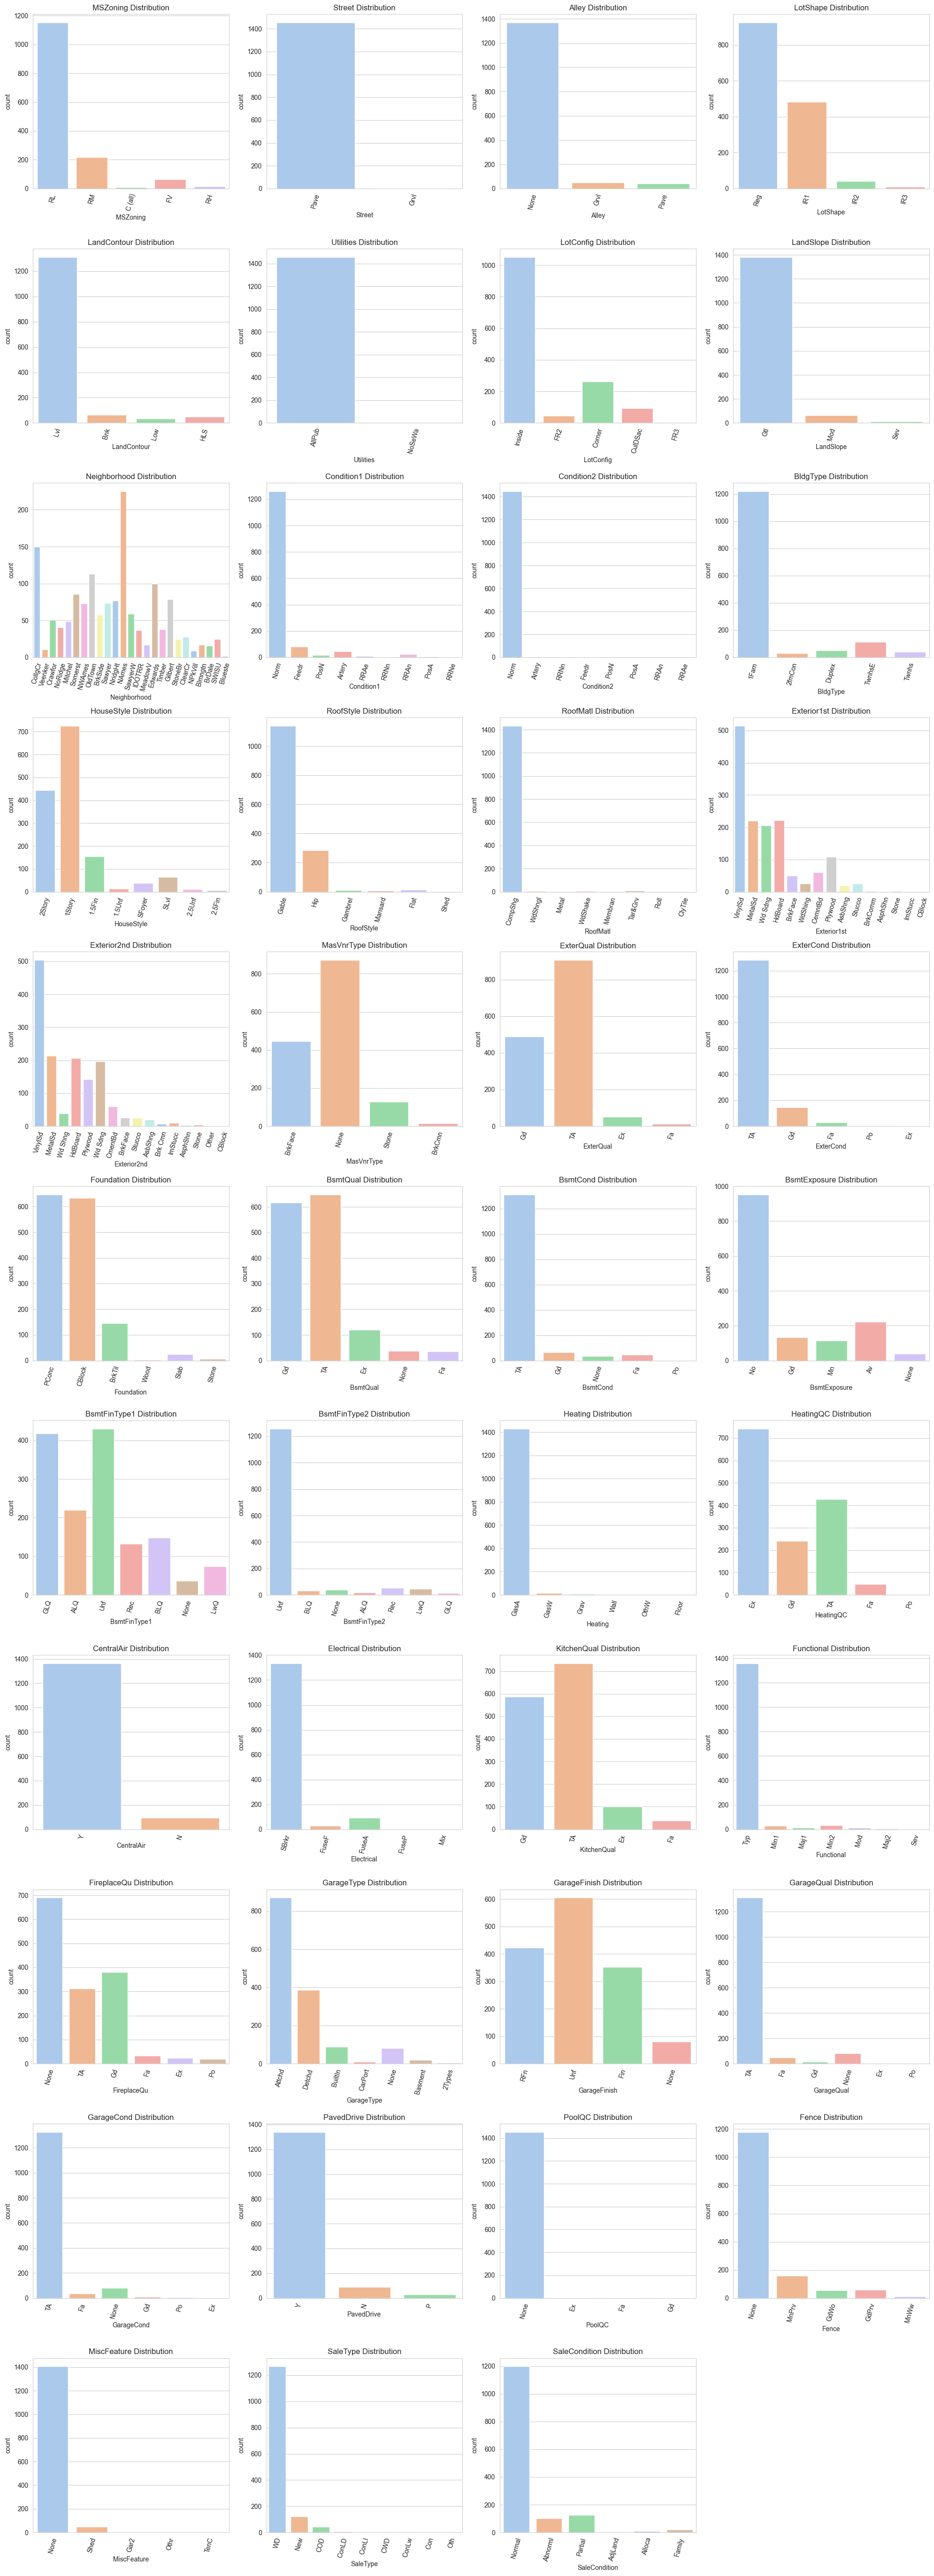

In [268]:
# categorical columns
cat_cols = train.select_dtypes(include=['object']).columns
cols_per_row = 4
num_plots = len(cat_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.countplot(data=train, x=col, hue=col, palette='pastel', legend=False)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=75)
    plt.tight_layout()
plt.show()

The categorical feature distributions show clear patterns in housing preferences and construction norms within the dataset. Many categories are highly imbalanced, meaning certain building characteristics are far more common than others. For example, most homes are located in residential zones (MSZoning = RL) and are accessed by paved streets, reflecting typical suburban development patterns. Neighborhood distribution varies widely, with a few neighborhoods contributing a large share of homes, indicating potential location-driven pricing differences to be explored.

Quality-related categorical variables, such as Exterior, KitchenQual, BsmtQual, and ExterCond, show that most homes fall within average to good quality ranges, with extreme poor or excellent ratings being relatively rare. This suggests the housing stock is mostly mid-range in condition. Features such as PoolArea, 3SsnPorch, and certain garage attributes also display strong imbalance, where the majority of homes lack these amenities entirely. These features will likely require binary encoding or careful handling during modeling to avoid noise.

Overall, the categorical distributions highlight the importance of location, overall condition, and house style, while also signaling that many amenity features are sparsely represented. These imbalances indicate where feature simplification, grouping, or ordinal encoding will improve model interpretability and performance.

# Outlier handling

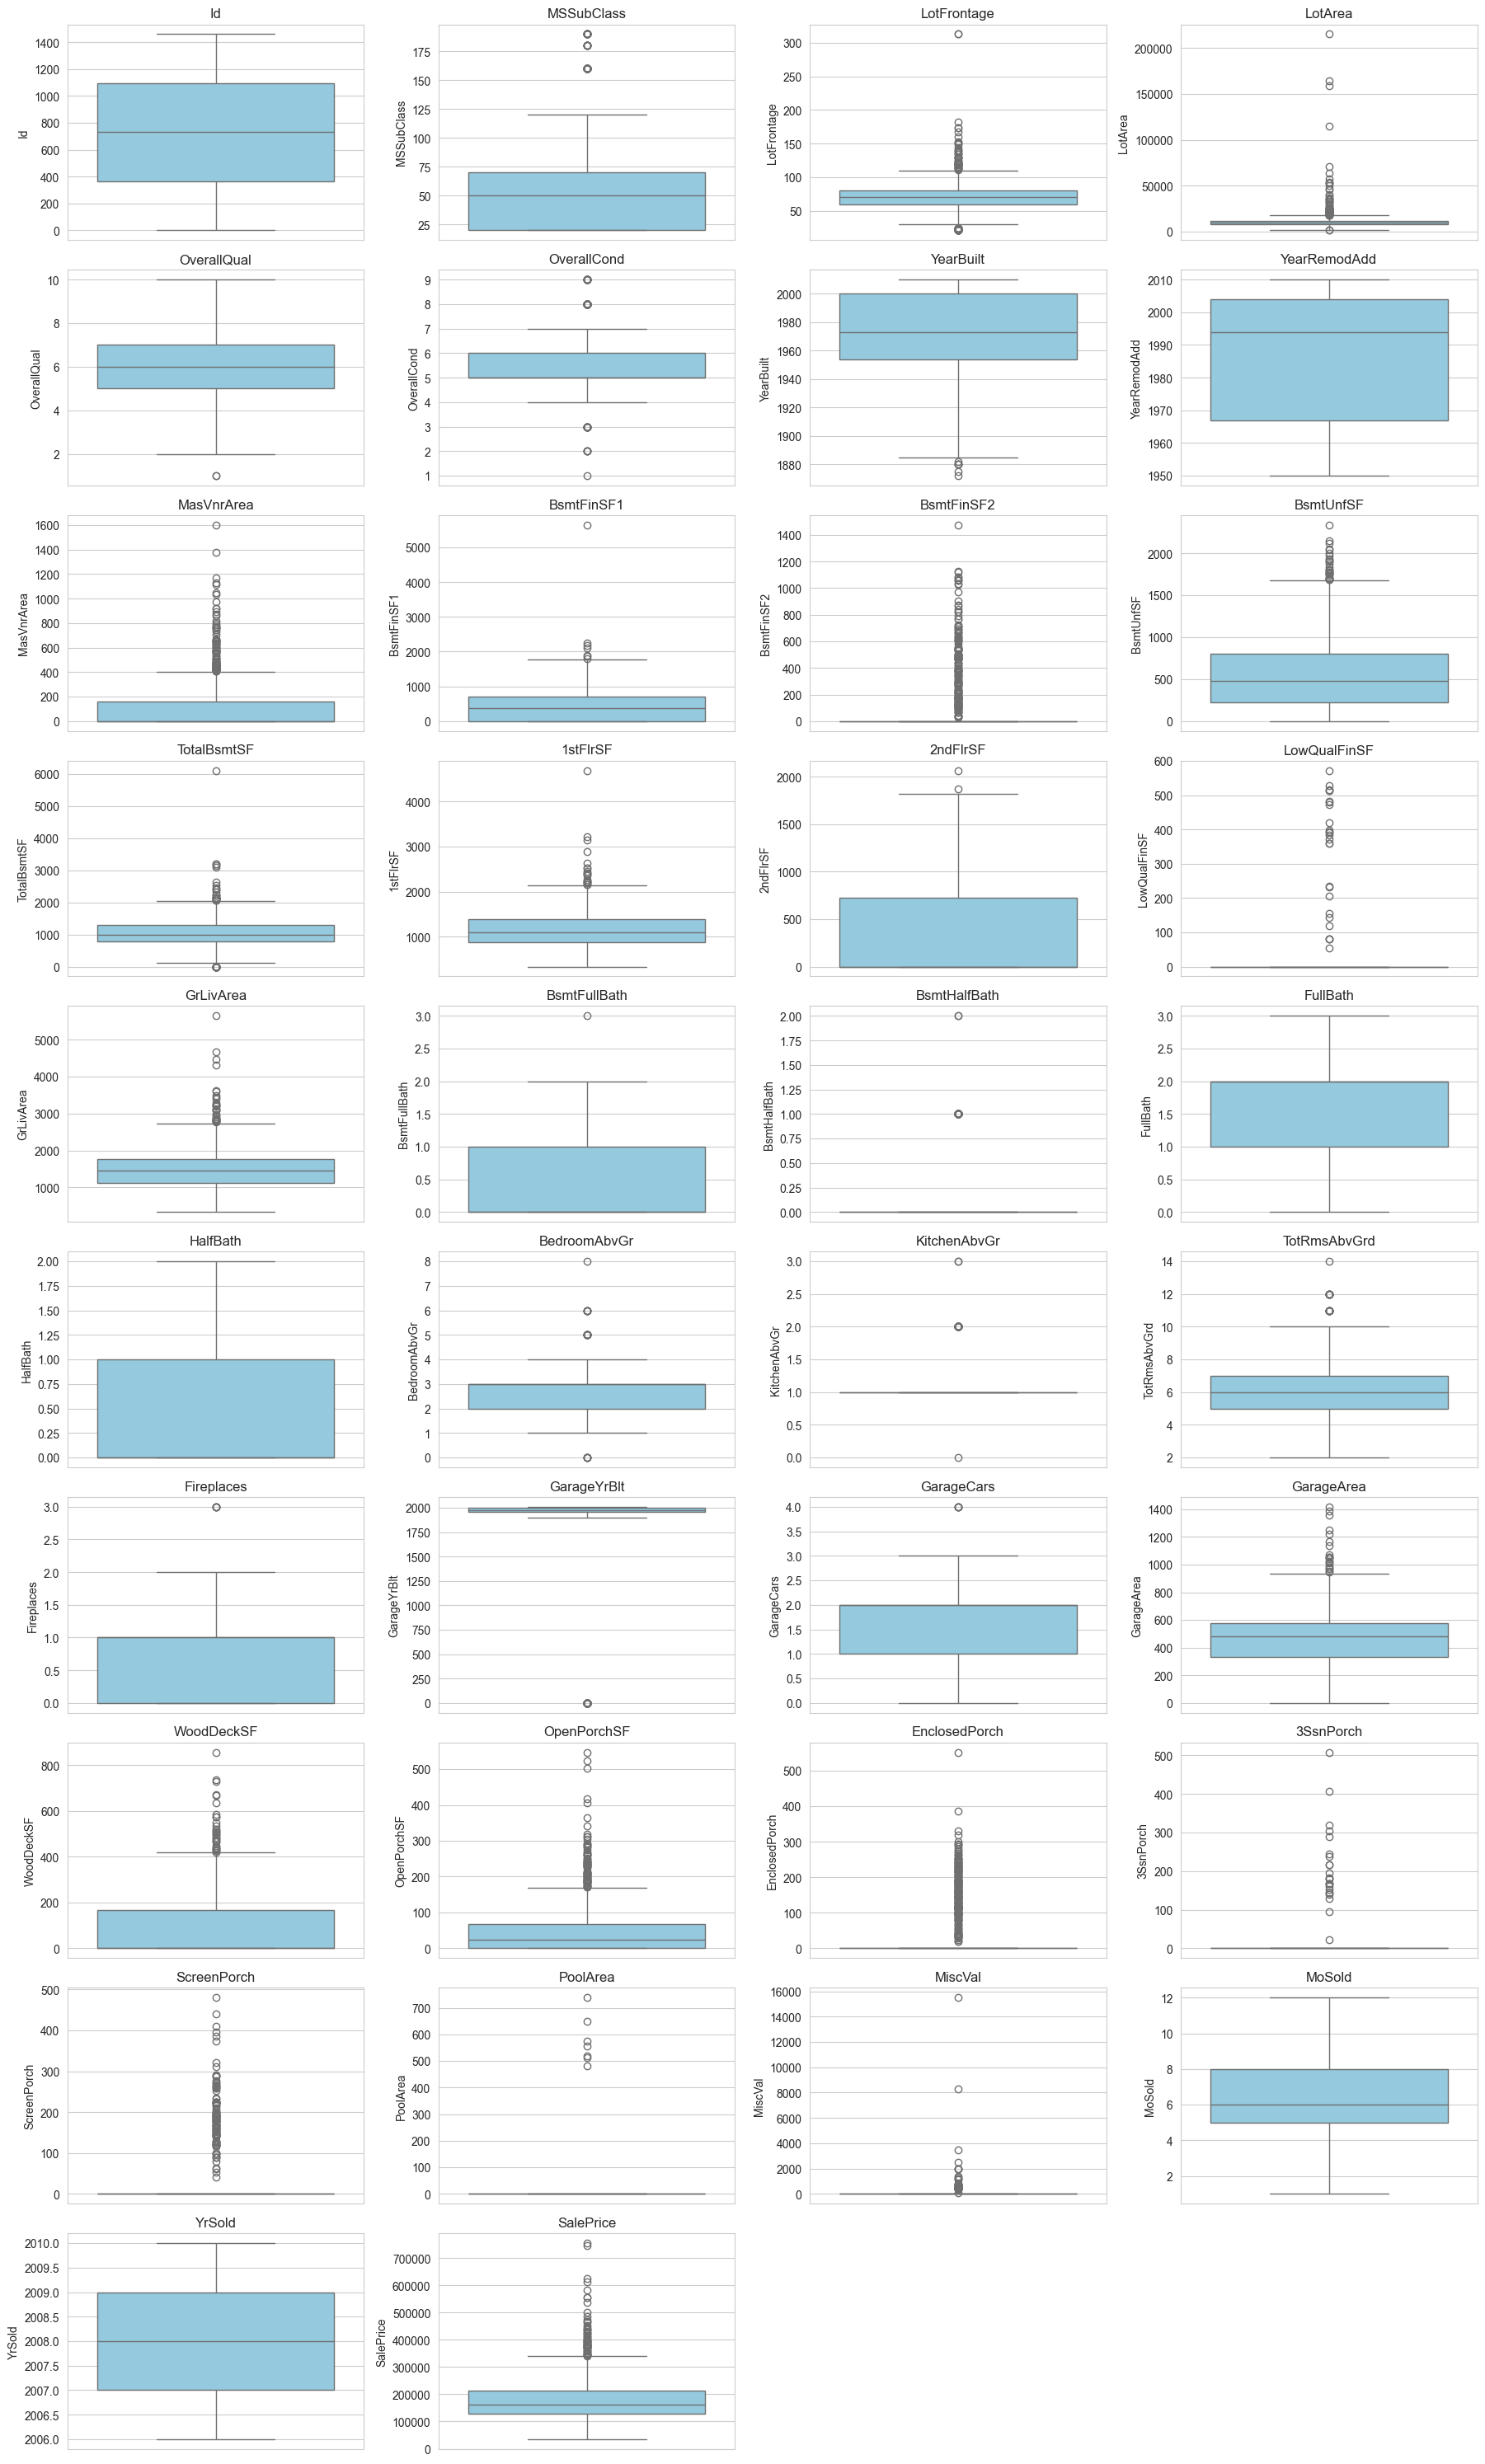

In [269]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()

cols = 4
rows = math.ceil(len(num_cols) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=train[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [270]:
train = train.copy()
test = test.copy()

# Remove extreme case (GrLivArea)
if 'GrLivArea' in train.columns and 'SalePrice' in train.columns:
    before = train.shape[0]
    train = train.loc[~((train['GrLivArea'] > 4500) & (train['SalePrice'] < 700000))].copy()
    after = train.shape[0]
    print(f"GrLivArea rule removed {before-after} rows ({(before-after)/before:.2%})")

def ensure_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

iqr_cols = [
    'LotArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF',
    '1stFlrSF', 'GrLivArea', 'GarageArea', 'TotalSF'
]
iqr_cols = [c for c in iqr_cols if c in train.columns]
ensure_numeric(train, iqr_cols)
ensure_numeric(test, iqr_cols)

# IQR bounds
def get_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

iqr_bounds = {}
for col in iqr_cols:
    lower, upper = get_iqr_bounds(train[col].dropna())
    if lower < 0 and train[col].min() >= 0:
        lower = 0.0
    iqr_bounds[col] = (lower, upper)

    before = train.shape[0]
    train = train.loc[(train[col] >= lower) & (train[col] <= upper)].copy()
    after = train.shape[0]
    print(f"{col}: Removed {before - after} rows ({(before-after)/before:.2%})")

for col, (lower, upper) in iqr_bounds.items():
    if col in test.columns:
        test[col] = pd.to_numeric(test[col], errors='coerce').fillna(lower)
        test[col] = test[col].clip(lower=lower, upper=upper)

# Winsorize
cap_cols = ['WoodDeckSF', 'OpenPorchSF', 'MasVnrArea', 'BsmtFinSF2']
cap_cols = [c for c in cap_cols if c in train.columns]

cap_values = {}
for col in cap_cols:
    upper_cap = train[col].quantile(0.99)
    cap_values[col] = upper_cap
    train[col] = np.where(train[col] > upper_cap, upper_cap, train[col])
    if col in test.columns:
        test[col] = pd.to_numeric(test[col], errors='coerce').fillna(0)
        test[col] = np.where(test[col] > upper_cap, upper_cap, test[col])

GrLivArea rule removed 2 rows (0.14%)
LotArea: Removed 66 rows (4.53%)
BsmtFinSF1: Removed 5 rows (0.36%)
BsmtUnfSF: Removed 30 rows (2.16%)
TotalBsmtSF: Removed 53 rows (3.91%)
1stFlrSF: Removed 6 rows (0.46%)
GrLivArea: Removed 26 rows (2.00%)
GarageArea: Removed 6 rows (0.47%)


Outliers were examined visually using boxplots and assessed statistically using the Interquartile Range (IQR) method. Several continuous variables displayed strong right-skew and extreme high values, particularly those related to property size such as LotArea, BsmtFinSF1, BsmtUnfSF, TotalBsmtSF, 1stFlrSF, GrLivArea, GarageArea, and the engineered TotalSF feature. Because extreme values in these features can distort model training and inflate error, we removed outliers falling beyond 1.5 × IQR for these variables. Additionally, we removed unusually large homes with very low sale prices in the GrLivArea feature. For variables with many zeros and a few extremely large values (e.g., MasVnrArea, WoodDeckSF, OpenPorchSF, BsmtFinSF2), we capped extreme values at the 99th percentile instead of removing observations, in order to preserve dataset size and maintain underlying distribution patterns. Overall, this balanced strategy ensures that the dataset remains representative while reducing the influence of extreme, non-typical values on model performance.

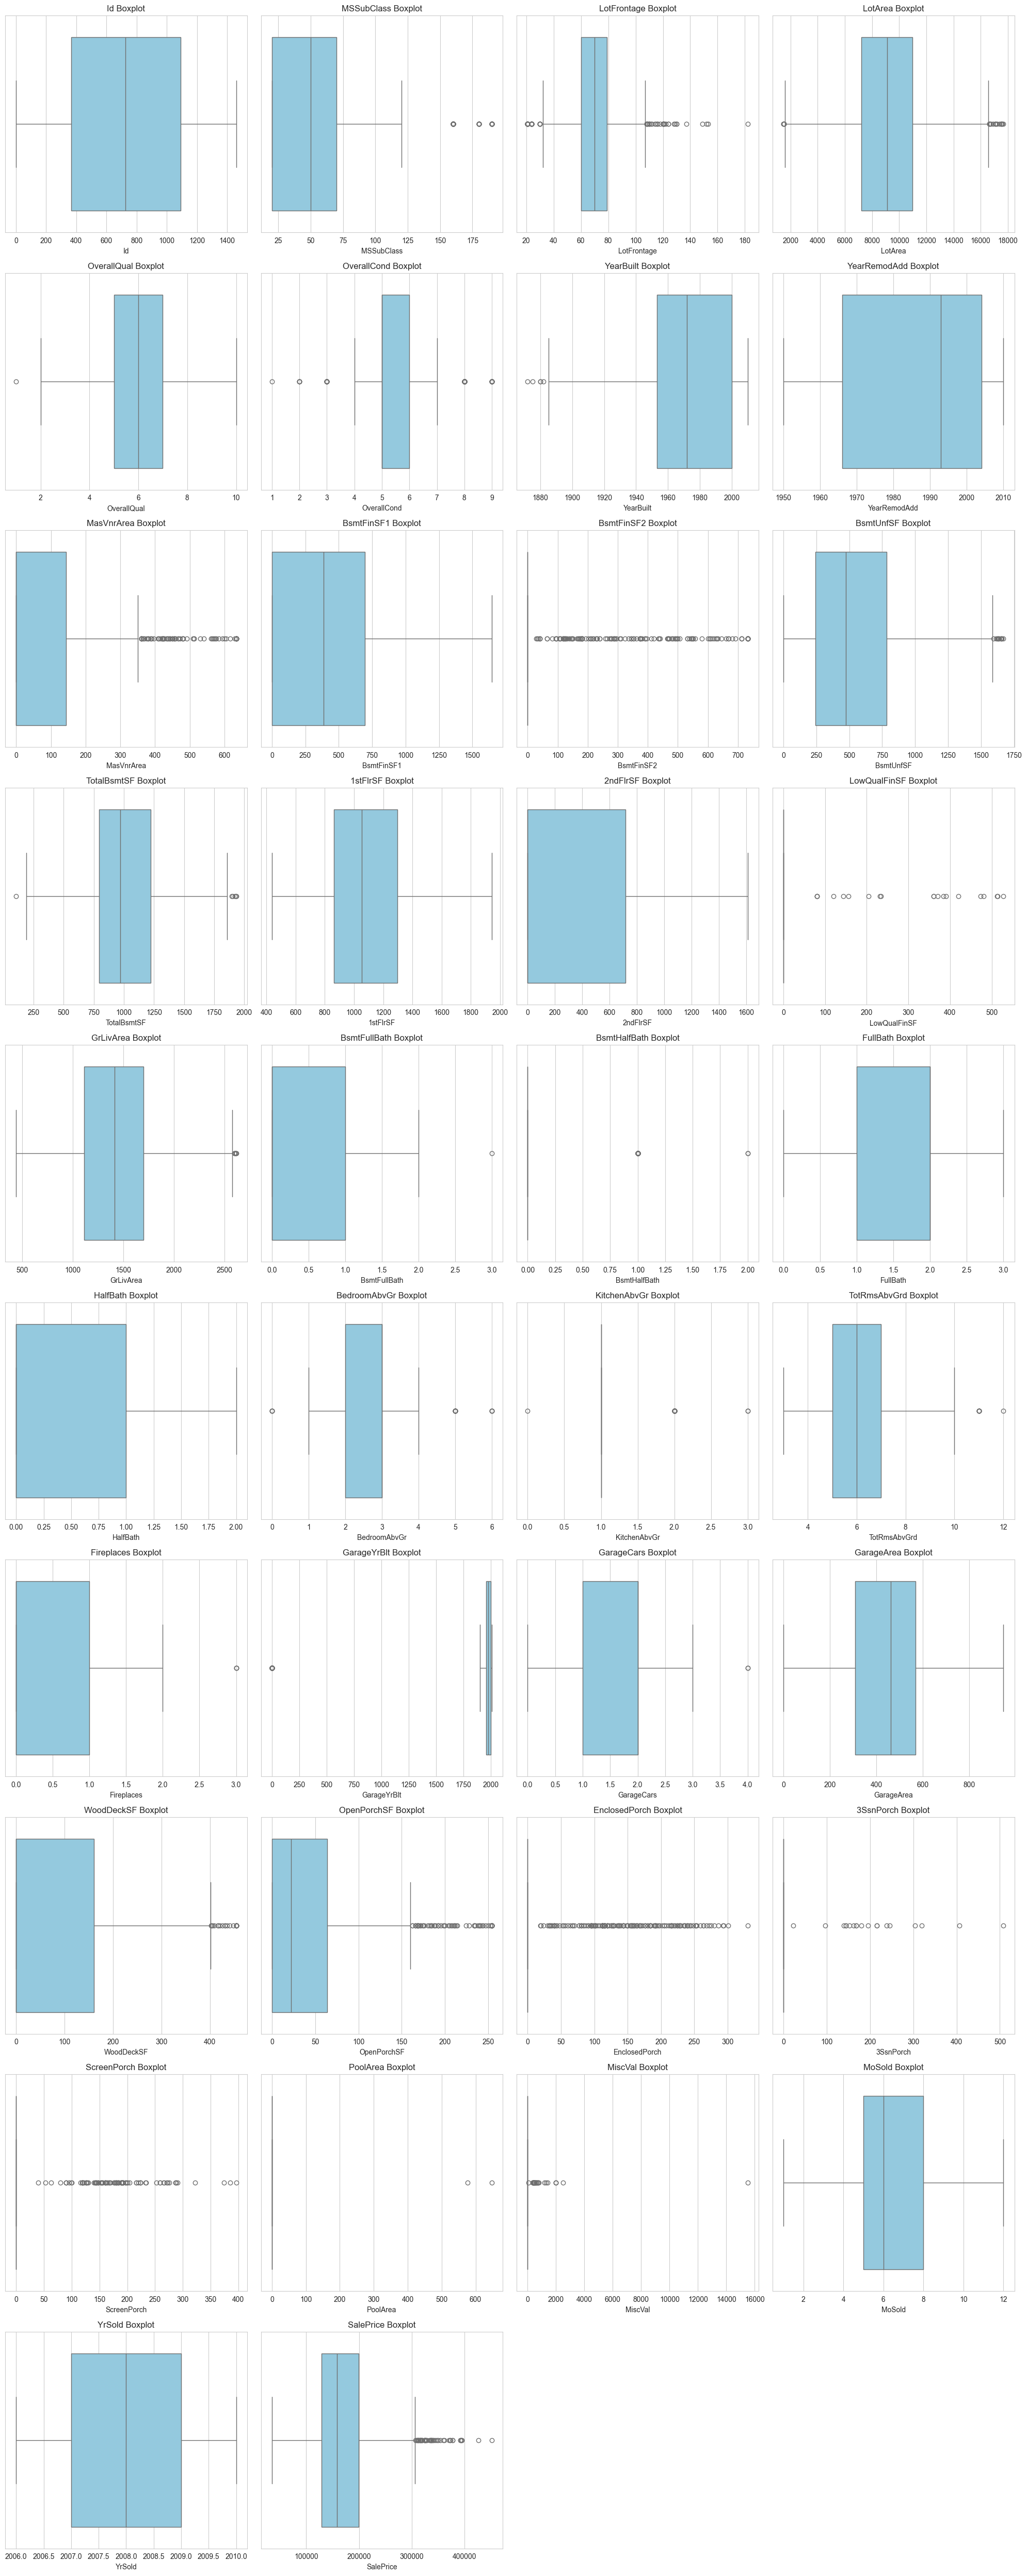

In [271]:
# boxplots after outlier handling
num_cols = train.select_dtypes(include=np.number).columns.tolist()

cols_per_row = 4
num_plots = len(num_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(x=train[col], color="skyblue")
    plt.title(f"{col} Boxplot")
    plt.tight_layout()

plt.show()

## Biveriate analysis

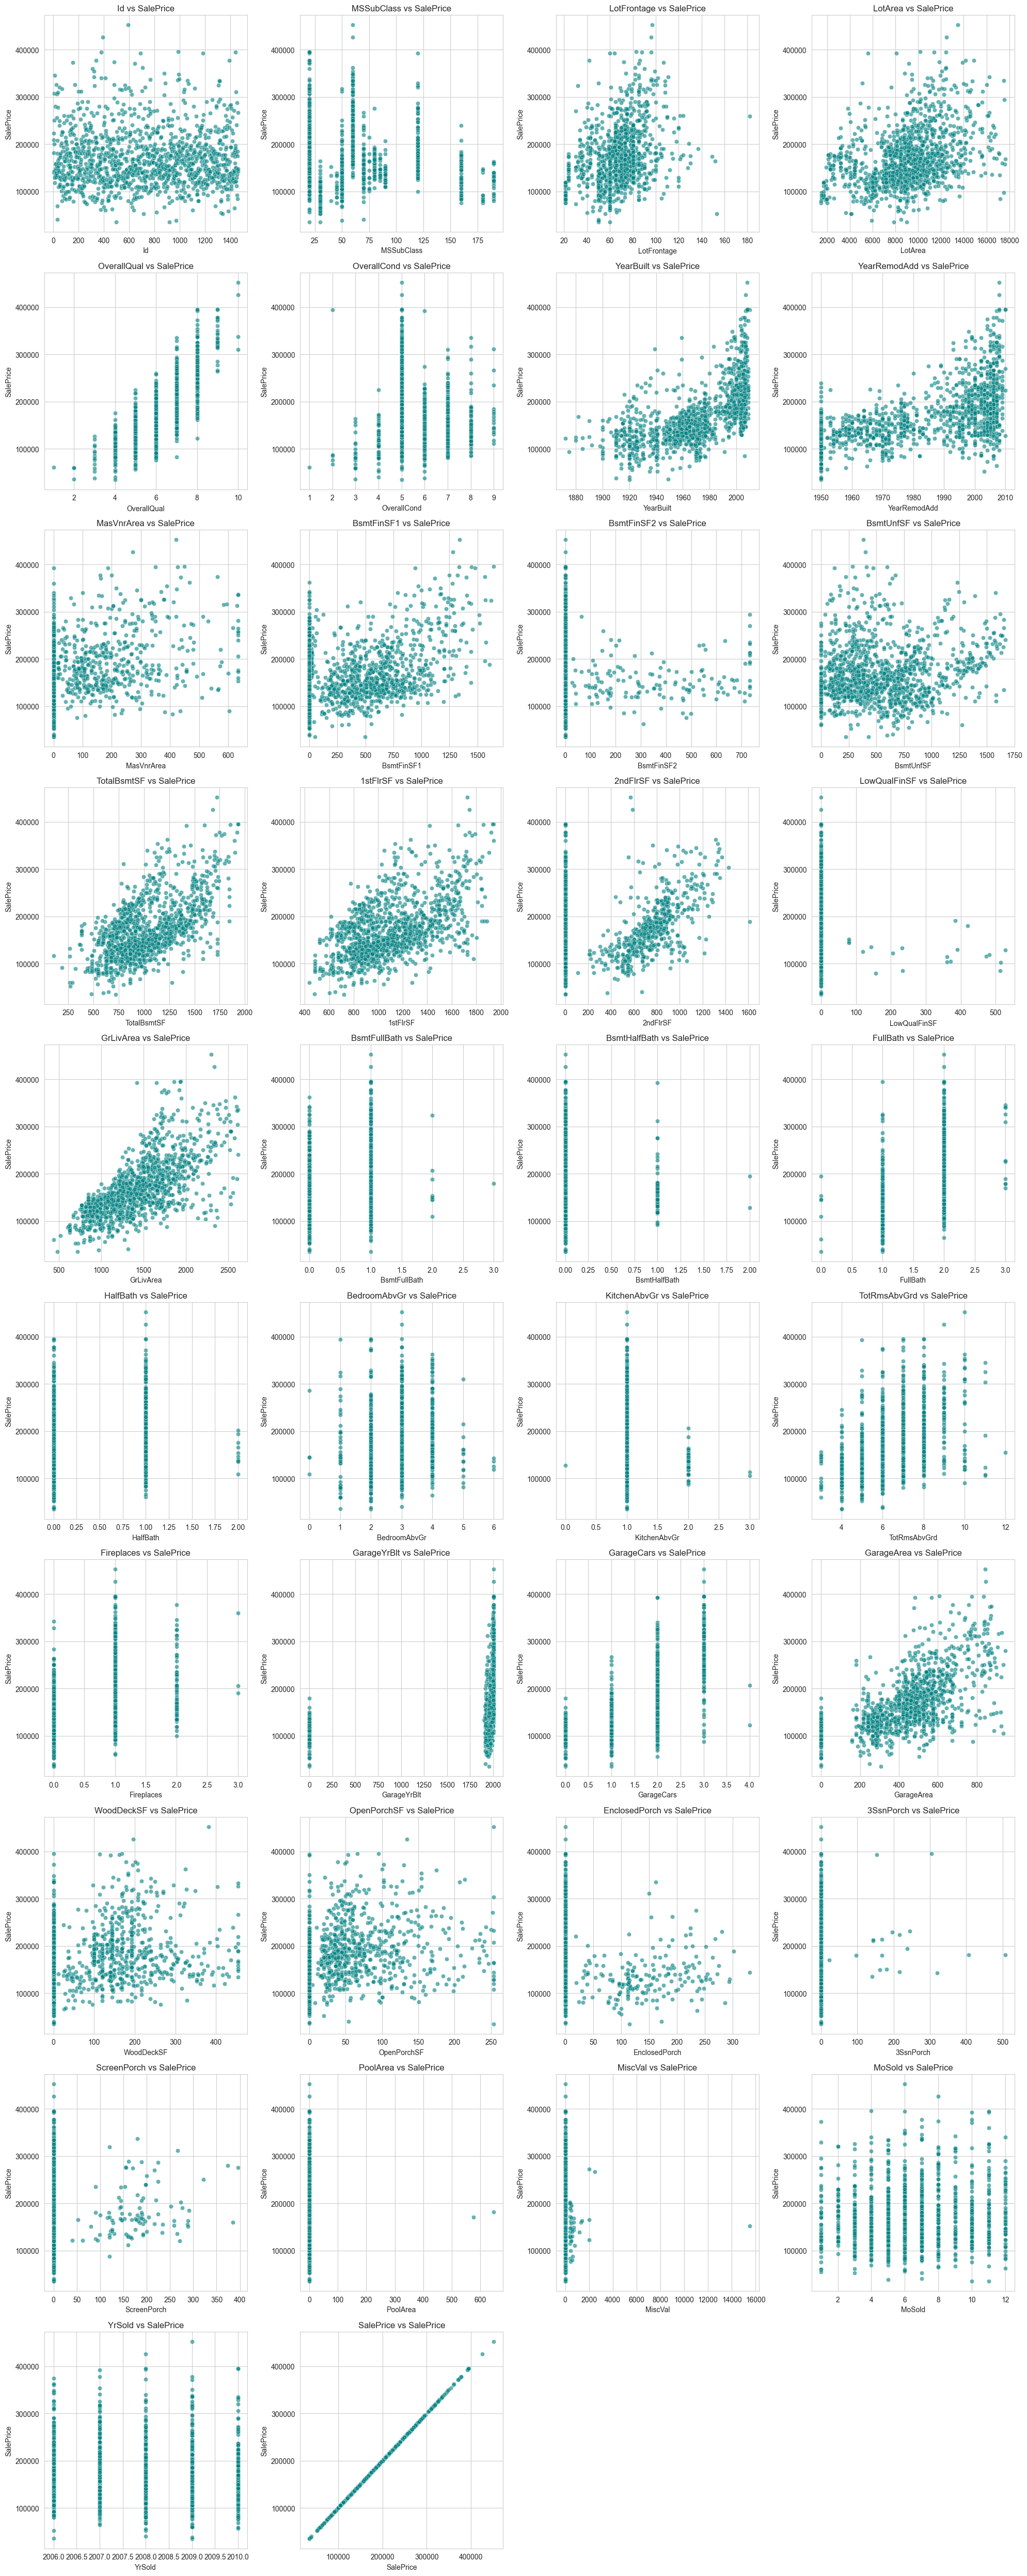

In [272]:
# Numerical vs Target
cols_per_row = 4
num_plots = len(num_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.scatterplot(data=train, x=col, y='SalePrice', color='teal', alpha=0.6)
    plt.title(f'{col} vs SalePrice')
plt.tight_layout()
plt.show()

The scatterplots show that several numeric features have a clear linear relationship with SalePrice, especially size-related variables such as GrLivArea, TotalBsmtSF, 1stFlrSF, and GarageArea. These features display upward-sloping patterns, meaning larger homes consistently sell for higher prices. Quality indicators like OverallQual also show strong positive trends, reinforcing that better-quality houses attract higher prices. In contrast, smaller or rarely occurring features—such as MiscVal, LowQualFinSF, or 3SsnPorch—show little to no linear pattern with SalePrice, indicating minimal predictive value. Overall, size and quality remain the strongest linear drivers of property prices.

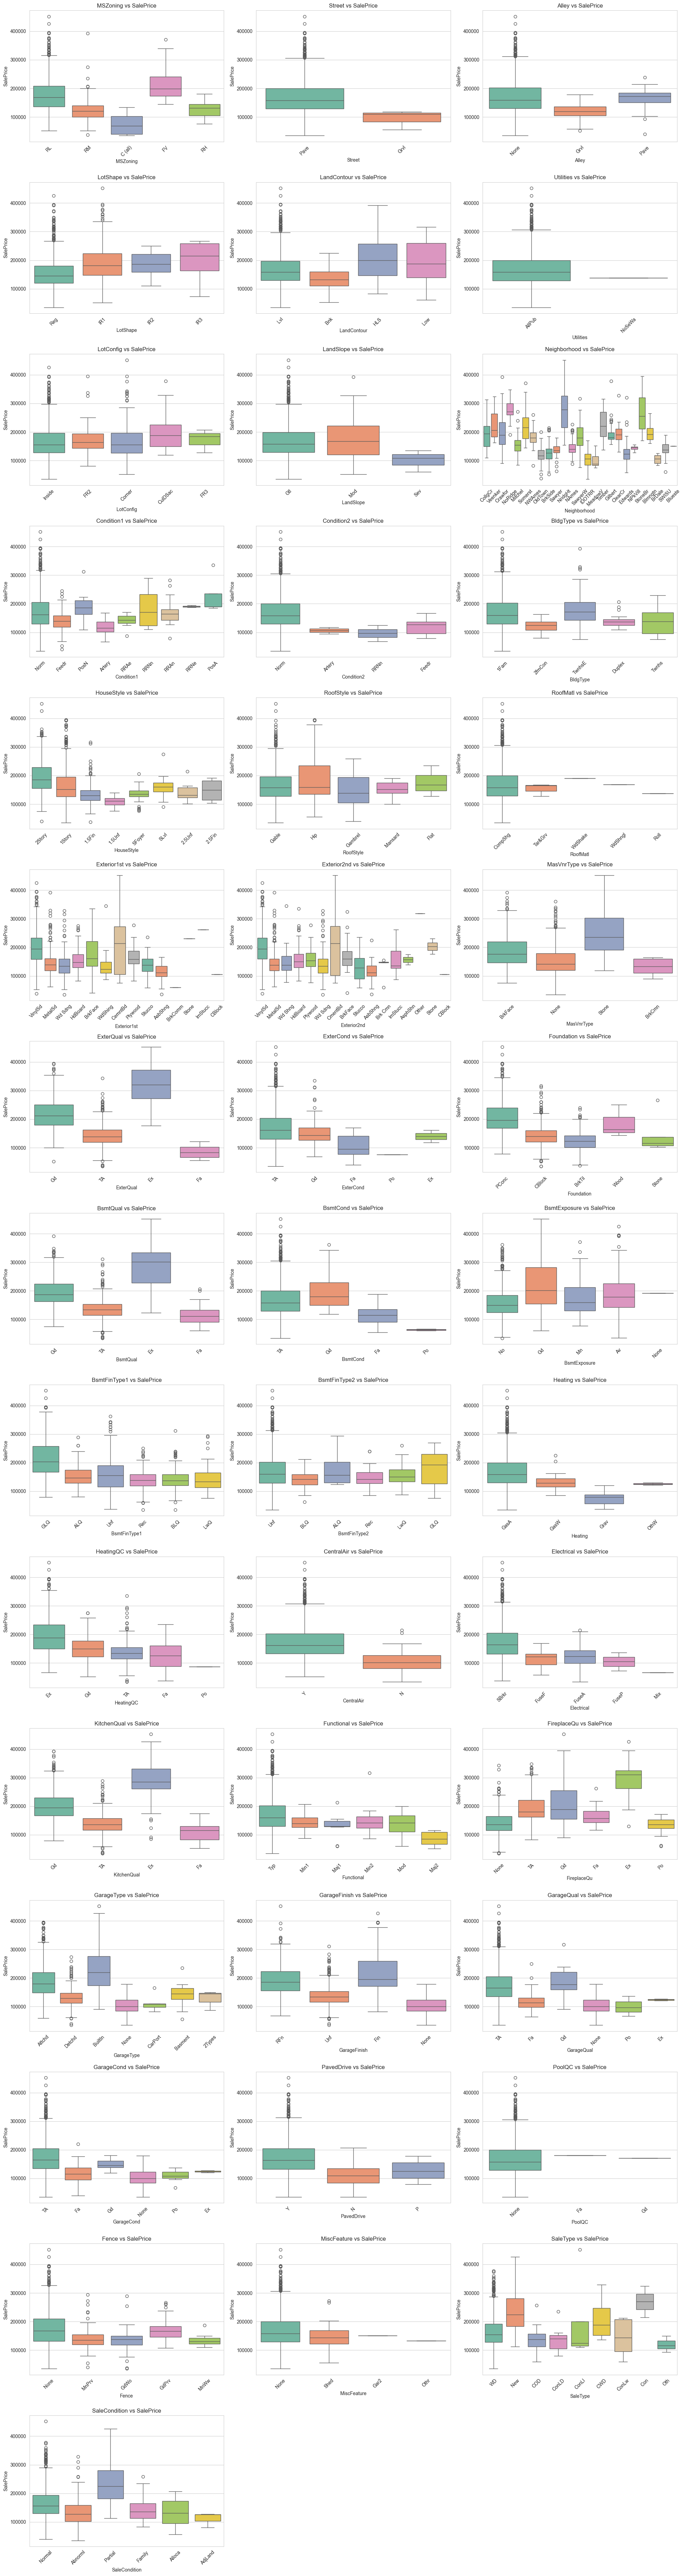

In [273]:
# categorical vs SalePrice
cols_per_row = 3
num_plots = len(cat_cols)
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(20, 5 * rows))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(data=train, x=col, y='SalePrice', hue=col, palette='Set2', legend=False)
    plt.title(f'{col} vs SalePrice')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

The bivariate analysis of categorical features against SalePrice highlights several patterns in how structural quality, location, and property characteristics influence home values. Neighborhood stands out as one of the strongest categorical predictors of price, with certain areas such as *StoneBr*, *NridgHt*, and *NoRidge* consistently associated with significantly higher sale prices. This suggests a clear location-based premium in the housing market. Conversely, neighborhoods like *MeadowV* and *IDOTRR* show noticeably lower price ranges, indicating market segmentation by locality.

Quality-related categorical variables also show meaningful gradients. For instance, homes with higher KitchenQual and ExterQual ratings show higher SalePrice distributions. This supports the pattern observed earlier that material and finish quality strongly influence perceived and market value. Similarly, BsmtQual and GarageQual show a positive association with price, although the effect is less pronounced than for above-ground quality indicators.

Some categorical variables showed limited or no variation in relation to SalePrice. For example, Utilities and Street show almost no discriminatory power because nearly all homes share the same category. These features offer little value and can be removed to simplify the model without information loss. RoofStyle, Heating type, and Functional categories also showed only weak price differentiation, suggesting these features carry less predictive weight.

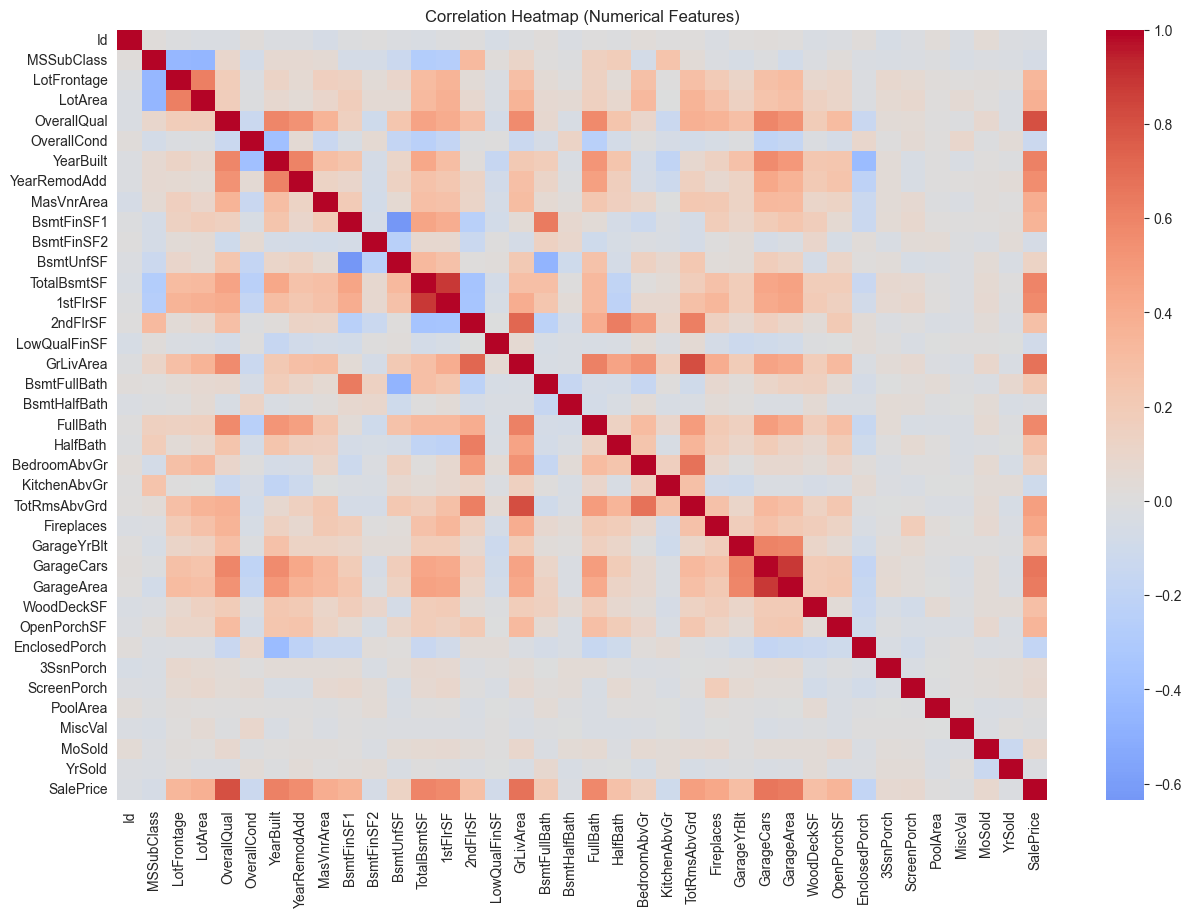

In [274]:
# correlation matrix
corr = train.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

In [275]:
corr.SalePrice.sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.802557
GrLivArea        0.675159
GarageCars       0.656674
GarageArea       0.631551
YearBuilt        0.612143
TotalBsmtSF      0.595117
FullBath         0.583877
1stFlrSF         0.566400
YearRemodAdd     0.555147
TotRmsAbvGrd     0.471698
Fireplaces       0.425236
MasVnrArea       0.395527
LotArea          0.377426
BsmtFinSF1       0.358776
OpenPorchSF      0.345428
LotFrontage      0.336315
GarageYrBlt      0.296604
WoodDeckSF       0.291412
2ndFlrSF         0.275339
HalfBath         0.267893
BsmtFullBath     0.217331
BedroomAbvGr     0.156169
BsmtUnfSF        0.130781
MoSold           0.081968
ScreenPorch      0.079173
3SsnPorch        0.067937
PoolArea         0.004157
MiscVal         -0.013144
YrSold          -0.020926
Id              -0.023199
BsmtHalfBath    -0.026285
MSSubClass      -0.055695
BsmtFinSF2      -0.057522
LowQualFinSF    -0.087525
KitchenAbvGr    -0.110197
OverallCond     -0.123500
EnclosedPorch   -0.181776
Name: SalePr

The correlation analysis shows that house quality and size are the strongest drivers of sale price. OverallQual has the highest positive correlation with SalePrice, followed by GrLivArea, GarageCars, GarageArea, TotalBsmtSF, and YearBuilt/YearRemodAdd, indicating that larger homes with better construction and more recent updates tend to sell for higher prices. Features such as KitchenAbvGr, LowQualFinSF, and EnclosedPorch show weak or negative correlations, suggesting they contribute little to price variation and may be less important in modeling. Additionally, several size-related features are strongly correlated with one another.

## Multivariate analysis

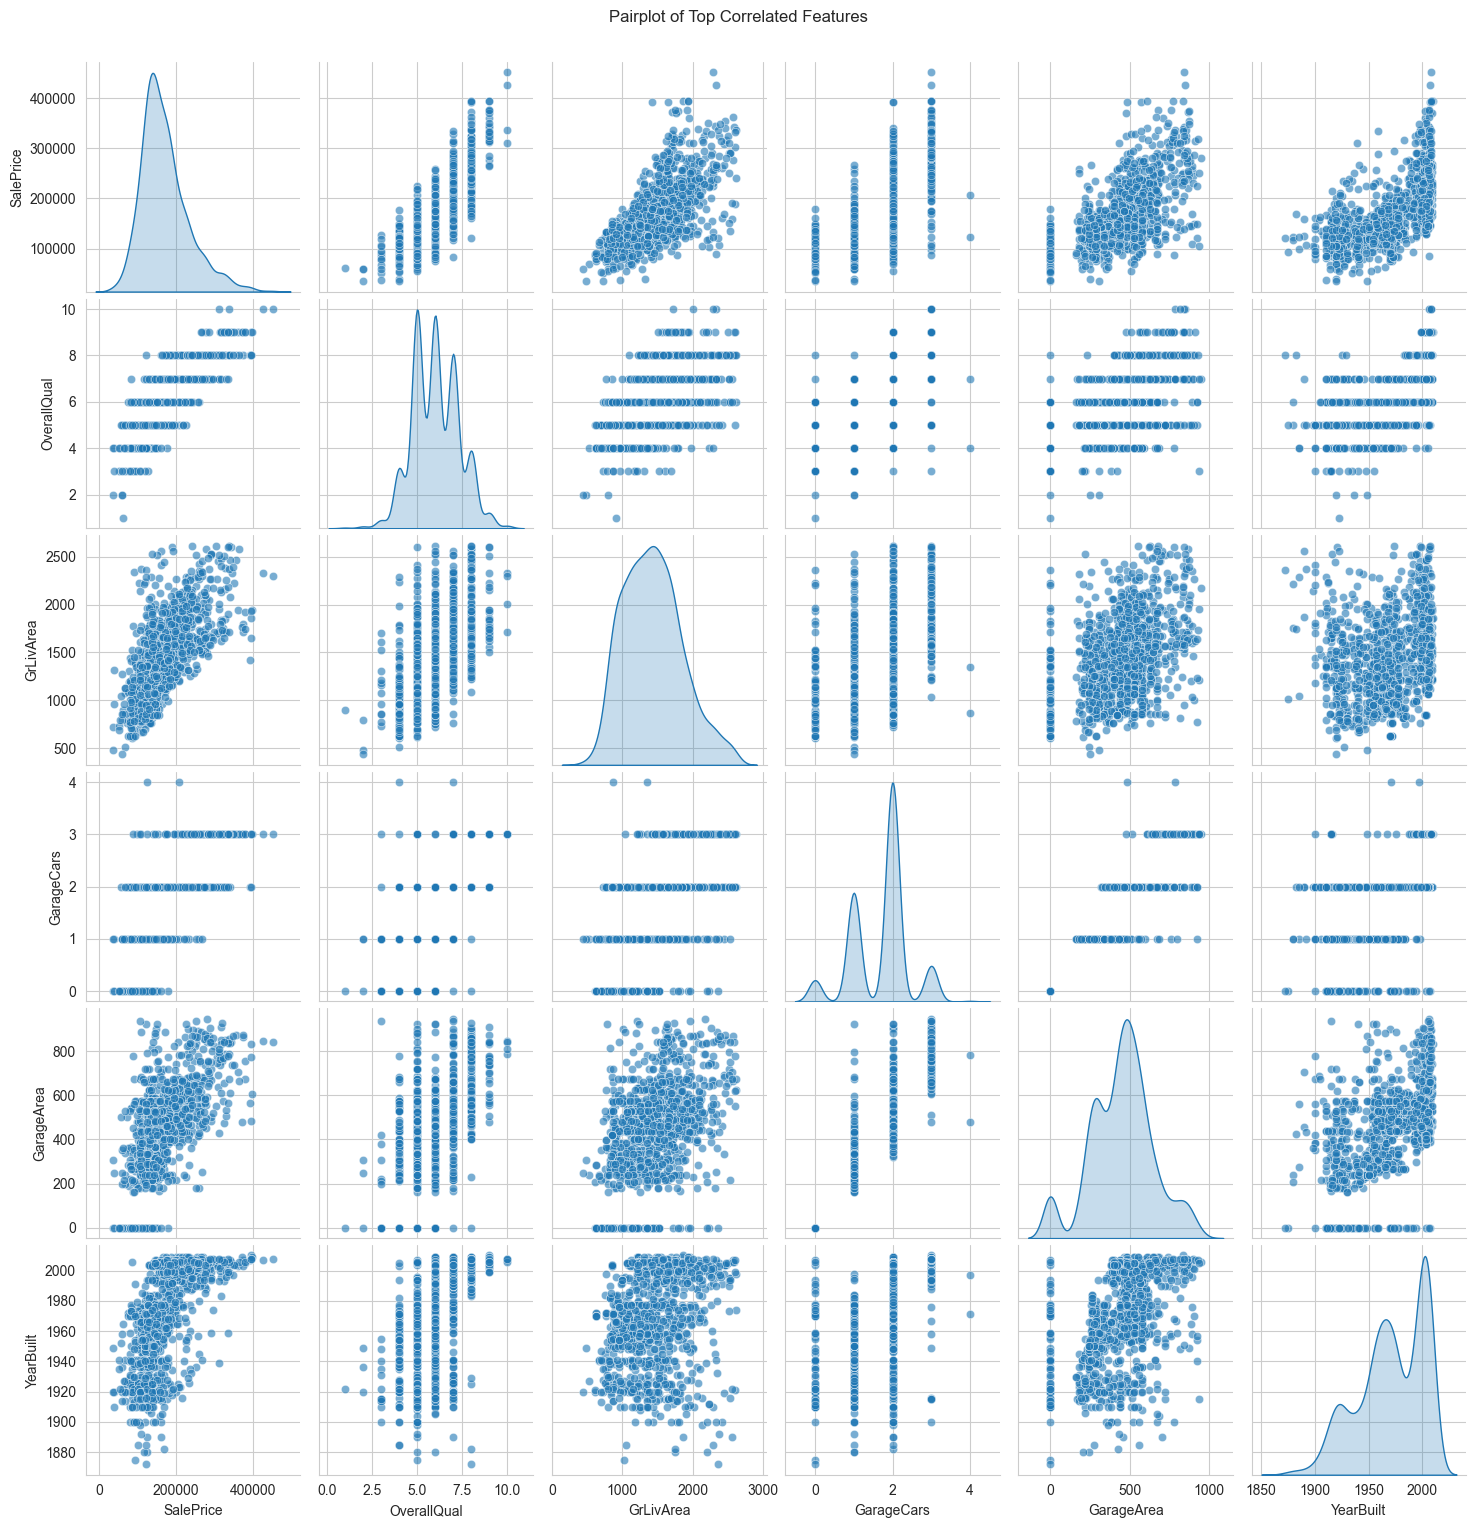

In [276]:
# Pairplot for top correlated numeric variables
corr_matrix = train.corr(numeric_only=True)

top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(6).index

sns.pairplot(train[top_corr], diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of Top Correlated Features', y=1.02)
plt.show()

The pairplot highlights the strongest relationships between the top correlated features and SalePrice. Size-related features like GrLivArea, GarageArea, and GarageCars show clear positive upward trends—larger living spaces and bigger garages consistently correspond to higher sale prices. OverallQual displays one of the strongest patterns, with prices rising sharply as quality improves. FullBath also shows a mild positive association, reflecting the added value of more bathrooms. The density plots on the diagonal further show well-distributed continuous features and more discrete patterns in categorical-like variables. Overall, the pairplot confirms that home size and quality are the most influential drivers of price.

In [277]:
# Multicollinearity (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = train[['TotalBsmtSF','GrLivArea','GarageCars','GarageArea','OverallQual','YearBuilt']].assign(const=1)
vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif

,Feature,VIF
0,TotalBsmtSF,1.402952
1,GrLivArea,1.610487
2,GarageCars,5.328207
3,GarageArea,4.760433
4,OverallQual,2.361626
5,YearBuilt,1.874065
6,const,7291.735217


The VIF results show that multicollinearity is generally low indicating that these predictors provide mostly independent information to the model. They remain within acceptable limits and are safe to keep. Overall, multicollinearity is not a concern in the dataset.

## Encoding

In [278]:
# ordinal
quality_map = {"Ex":5,"Gd":4,"TA":3,"Fa":2,"Po":1,"None":0}
bsmt_exposure_map = {"Gd":4,"Av":3,"Mn":2,"No":1,"None":0}
bsmt_fin_map = {"GLQ":6,"ALQ":5,"BLQ":4,"Rec":3,"LwQ":2,"Unf":1,"None":0}
functional_map = {"Typ":7,"Min1":6,"Min2":5,"Mod":4,"Maj1":3,"Maj2":2,"Sev":1,"Sal":0}
paved_map = {"Y":2,"P":1,"N":0}
fence_map = {"GdPrv":4,"MnPrv":3,"GdWo":2,"MnWw":1,"None":0}
pool_map = {"Ex":4,"Gd":3,"TA":2,"Fa":1,"None":0}
garage_finish_map = {"Fin":3,"RFn":2,"Unf":1,"None":0}
garage_qual_map = {"Ex":5,"Gd":4,"TA":3,"Fa":2,"Po":1,"None":0}

feature_maps = {
    "ExterQual": quality_map,
    "ExterCond": quality_map,
    "HeatingQC": quality_map,
    "KitchenQual": quality_map,
    "FireplaceQu": quality_map,

    "BsmtQual": quality_map,
    "BsmtCond": quality_map,
    "BsmtExposure": bsmt_exposure_map,
    "BsmtFinType1": bsmt_fin_map,
    "BsmtFinType2": bsmt_fin_map,

    "GarageQual": garage_qual_map,
    "GarageCond": garage_qual_map,
    "GarageFinish": garage_finish_map,

    "Functional": functional_map,
    "PavedDrive": paved_map,
    "Fence": fence_map,
    "PoolQC": pool_map
}

def apply_feature_maps(df, feature_maps):
    df = df.copy()
    for col, mp in feature_maps.items():
        if col in df.columns:
            df[col] = df[col].fillna("None").astype(str)
            df[col] = df[col].map(lambda v: mp.get(v, 0)).astype(int)
    return df

train = apply_feature_maps(train, feature_maps)
test  = apply_feature_maps(test, feature_maps)

In [279]:
# One-Hot Encoding
one_hot_features = [
    "MSZoning", "LandContour", "LotConfig", "Neighborhood", "Condition1",
    "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl",
    "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating",
    "CentralAir", "Electrical", "GarageType", "MiscFeature", "SaleType",
    "SaleCondition", "Street", "Utilities", "LotShape", "LandSlope", "Alley"
]

one_hot_features = [col for col in one_hot_features if col in train.columns or col in test.columns]

combined = pd.concat([train, test], axis=0, ignore_index=True)
combined = pd.get_dummies(combined, columns=one_hot_features, drop_first=True)

train = combined.iloc[:len(train)].copy()
test  = combined.iloc[len(train):].copy()

In [280]:
if 'SalePrice' in test.columns:
    test = test.drop(columns=['SalePrice'])

train_feat_cols = [c for c in train.columns if c != 'SalePrice']

test = test.reindex(columns=train_feat_cols, fill_value=0)

if 'Id' in test.columns and 'Id' not in train_feat_cols:
    test_ids = test['Id'].copy()
    test = test.drop(columns=['Id'])

# Feature engineering

In [281]:
# 1. Total Square Footage
train['TotalSF'] = (
    train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
)

test['TotalSF'] = (
    test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']
)

# 2. Total Bathrooms
train['Total_Bathrooms'] = (
    train['FullBath'] 
    + 0.5 * train['HalfBath']
    + train['BsmtFullBath']
    + 0.5 * train['BsmtHalfBath']
)

test['Total_Bathrooms'] = (
    test['FullBath'] 
    + 0.5 * test['HalfBath']
    + test['BsmtFullBath']
    + 0.5 * test['BsmtHalfBath']
)

# 3. House Age Features
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
test['RemodAge'] = test['YrSold'] - test['YearRemodAdd']

train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

# 4. Quality × Size Interaction
train['OverallQualArea'] = train['OverallQual'] * train['TotalSF']
test['OverallQualArea'] = test['OverallQual'] * test['TotalSF']

train['QualityScore'] = train['OverallQual'] * train['OverallCond']
test['QualityScore'] = test['OverallQual'] * test['OverallCond']

# 5. Total Porch Area
train['TotalPorch'] = (
    train['OpenPorchSF'] + train['EnclosedPorch'] +
    train['ScreenPorch'] + train['3SsnPorch']
)

test['TotalPorch'] = (
    test['OpenPorchSF'] + test['EnclosedPorch'] +
    test['ScreenPorch'] + test['3SsnPorch']
)

In [282]:
print("Train:", train.shape)
print("Test:", test.shape)

Train: (1266, 207)
Test: (1459, 206)


In [283]:
test.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,...,LandSlope_Sev,Alley_None,Alley_Pave,TotalSF,Total_Bathrooms,RemodAge,HouseAge,OverallQualArea,QualityScore,TotalPorch
1266,1461,20,80.0,11622.0,5,6,1961,1961,0.0,3,...,False,True,False,1778.0,1.0,49,49,8890.0,30,120.0
1267,1462,20,81.0,14267.0,6,6,1958,1958,108.0,3,...,False,True,False,2658.0,1.5,52,52,15948.0,36,36.0
1268,1463,60,74.0,13830.0,5,5,1997,1998,0.0,3,...,False,True,False,2557.0,2.5,12,13,12785.0,25,34.0
1269,1464,60,78.0,9978.0,6,6,1998,1998,20.0,3,...,False,True,False,2530.0,2.5,12,12,15180.0,36,36.0
1270,1465,120,43.0,5005.0,8,5,1992,1992,0.0,4,...,False,True,False,2560.0,2.0,18,18,20480.0,40,226.0


# Train-test split

In [284]:
y = train["SalePrice"]
X = train.drop(["SalePrice", "Id"], axis=1)
test_ids = test["Id"]
X_test = test.drop(["Id"], axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", test.shape)

X_train: (1012, 205)
X_val:   (254, 205)
X_test:  (1459, 206)


# Model training

In [285]:
# Linear regression
pipe_lr = make_pipeline(
    StandardScaler(with_mean=False),
    PolynomialFeatures(degree=1),
    LinearRegression()
)

scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=5, scoring="r2")
print("Linear Regression R2 Scores:", scores_lr)
print("Mean R2:", scores_lr.mean(), "\n")

Linear Regression R2 Scores: [0.9205021  0.91523007 0.9229497  0.89125492 0.90602036]
Mean R2: 0.9111914281456549 



In [286]:
# Lasso Regression
pipe_lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.001, max_iter=100000, random_state=42)
)

scores_lasso = cross_val_score(pipe_lasso, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
print("Lasso R2 Scores:", scores_lasso)
print("Mean R2:", scores_lasso.mean())

Lasso R2 Scores: [0.92032619 0.91519704 0.92333613 0.8912874  0.90566243]
Mean R2: 0.9111618381451674


In [287]:
# Ridge Regression
pipe_ridge = make_pipeline(
    StandardScaler(with_mean=False),
    PolynomialFeatures(degree=1),
    Ridge(alpha=1.0, random_state=42)
)

scores_ridge = cross_val_score(pipe_ridge, X_train, y_train, cv=5, scoring="r2")
print("Ridge R2 Scores:", scores_ridge)
print("Mean R2:", scores_ridge.mean())

Ridge R2 Scores: [0.91951436 0.91385633 0.91727079 0.89565747 0.90732797]
Mean R2: 0.9107253827548734


In [288]:
# ElasticNet Regression
pipe_enet = make_pipeline(
    StandardScaler(with_mean=False),
    PolynomialFeatures(degree=1),
    ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=20000, random_state=42)
)

scores_enet = cross_val_score(pipe_enet, X_train, y_train, cv=5, scoring="r2")
print("ElasticNet R2 Scores:", scores_enet)
print("Mean R2:", scores_enet.mean())

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.065e+10, tolerance: 3.011e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.190e+10, tolerance: 3.000e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

ElasticNet R2 Scores: [0.9205267  0.91525859 0.92150875 0.89295911 0.90671541]
Mean R2: 0.9113937126060344


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.755e+10, tolerance: 2.990e+08
  model = cd_fast.enet_coordinate_descent(


In [289]:
# Random forest
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print("RandomForest R² scores:", rf_scores)
print("Mean R²:", rf_scores.mean())

RandomForest R² scores: [0.90480157 0.91339629 0.90963073 0.89413566 0.87738318]
Mean R²: 0.8998694860300391


In [290]:
# Gradient boosting
gbr = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

gbr_scores = cross_val_score(gbr, X_train, y_train, cv=5, scoring='r2')
print("GradientBoosting R² scores:", gbr_scores)
print("Mean R²:", gbr_scores.mean())

GradientBoosting R² scores: [0.9187476  0.91593352 0.91544239 0.90471039 0.89881031]
Mean R²: 0.9107288406000895


In [291]:
# XG Boost
xgb = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2')
print("XGBoost R² scores:", xgb_scores)
print("Mean R²:", xgb_scores.mean())

XGBoost R² scores: [0.91823139 0.92777682 0.91974835 0.91134642 0.9080776 ]
Mean R²: 0.9170361162362919


In [292]:
# Support Vector Regression (SVR)
from sklearn.svm import SVR

svr = SVR(C=20, epsilon=0.2, kernel='rbf')
scores = cross_val_score(svr, X_train, y_train, cv=5, scoring="r2")
print("SVR mean R2:", scores.mean())

SVR mean R2: 0.0008937427605789638


Linear Regression, Lasso, Ridge, and ElasticNet all performed similarly with R² scores around 0.91, showing that the data follows mostly linear patterns. Among them, Ridge Regression was the most stable across folds because it handles correlated features better. I also tested Random Forest, Gradient boosting, SVR and XGBoost, and found that XGBoost performed the best overall, but Ridge was chosen as the main linear model due to its balance of accuracy, stability, and interpretability.

## Hyperparameter Optimization

Fitting 5 folds for each of 40 candidates, totalling 200 fits

===== GridSearch results =====
Best params:
{'polynomialfeatures__degree': 1,
 'ridge__alpha': np.float64(2.0691380811147897)}
Best CV RMSE (neg_root_mean_squared_error): 18023.6731

Per-fold RMSE: [17503.681  20583.1952 17208.6158 16388.9651 18433.9084]
Mean CV RMSE: 18023.6731
Mean CV R²: 0.9127


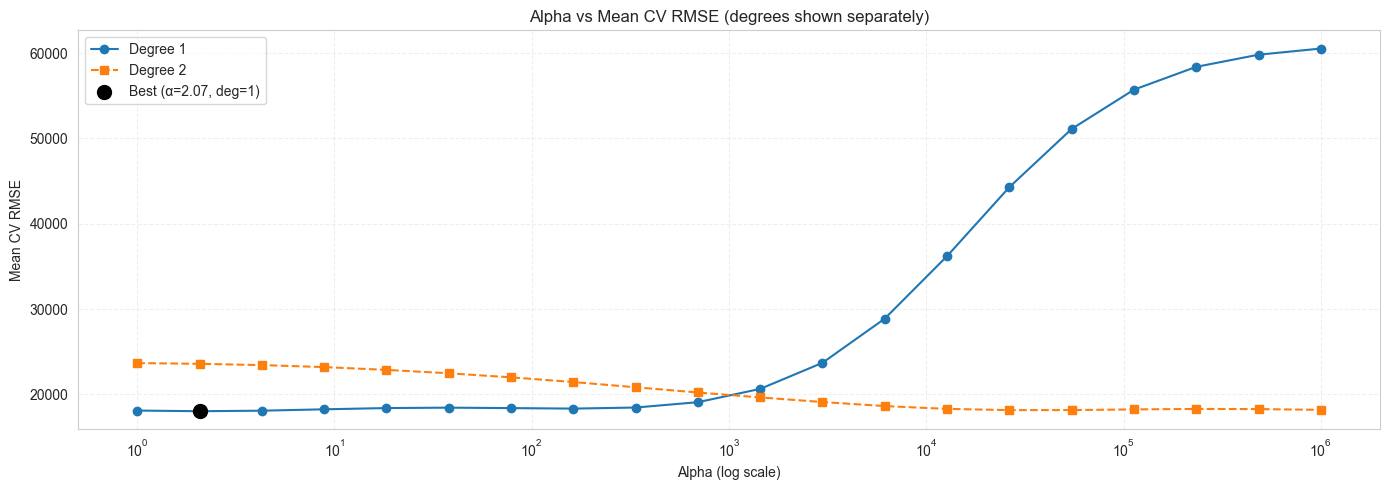

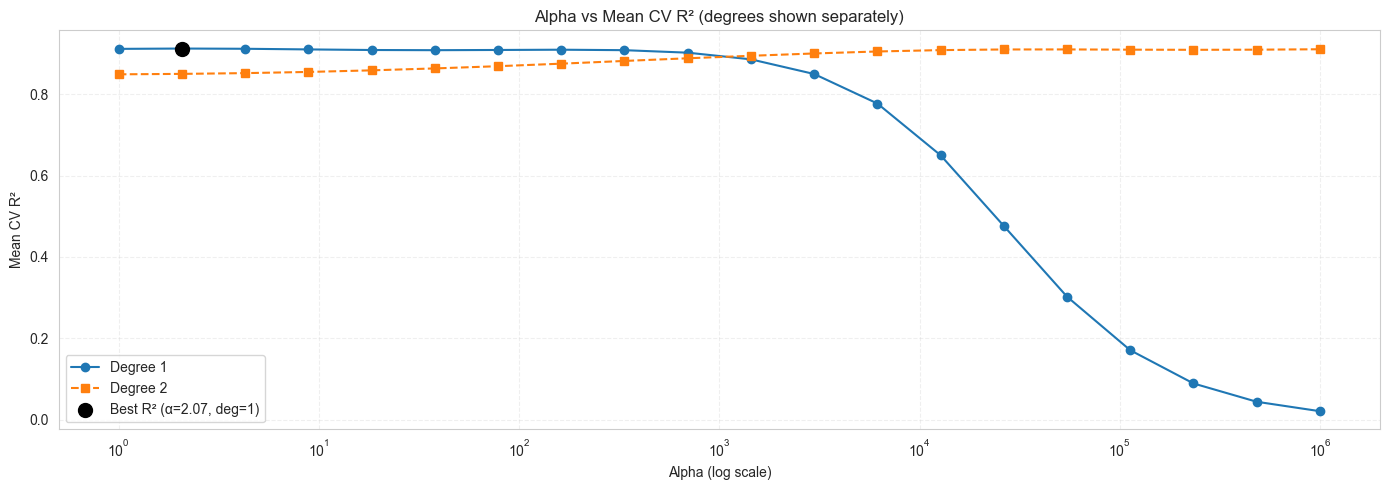


Best RMSE per degree:
 Degree 1 best alpha = 2.06914 -> RMSE = 18023.6731
 Degree 2 best alpha = 26366.5 -> RMSE = 18151.1390

Saved plots: alpha_vs_cv_rmse.png and alpha_vs_cv_r2.png


In [310]:
pipe_ridge = make_pipeline(
    StandardScaler(with_mean=False),
    PolynomialFeatures(include_bias=False),
    Ridge(random_state=42)
)

param_grid = {
    "polynomialfeatures__degree": [1, 2],
    "ridge__alpha": np.logspace(0, 6, 20)
}

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid,
    scoring=['neg_root_mean_squared_error', 'r2'],
    refit='neg_root_mean_squared_error', 
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

gs.fit(X_train, y_train)

best_params = gs.best_params_
best_neg_rmse = gs.best_score_
best_rmse = -best_neg_rmse

print("\n===== GridSearch results =====")
print("Best params:")
pprint.pprint(best_params)
print(f"Best CV RMSE (neg_root_mean_squared_error): {best_rmse:.4f}")

best_est = gs.best_estimator_
scoring = {"neg_rmse": "neg_root_mean_squared_error", "r2": "r2"}
cv_res = cross_validate(best_est, X_train, y_train, cv=cv_strategy,
                        scoring=scoring, n_jobs=-1, return_train_score=False)
per_fold_rmse = -cv_res["test_neg_rmse"]
print("\nPer-fold RMSE:", np.round(per_fold_rmse, 4))
print("Mean CV RMSE:", np.round(per_fold_rmse.mean(), 4))
print("Mean CV R²:", np.round(cv_res["test_r2"].mean(), 4))

res = gs.cv_results_
alphas = np.array([float(a) for a in res['param_ridge__alpha']])
degrees = np.array([int(d) for d in res['param_polynomialfeatures__degree']])
mean_rmse = -np.array(res['mean_test_neg_root_mean_squared_error'], dtype=float)
mean_r2 = np.array(res['mean_test_r2'], dtype=float)

order = np.argsort(alphas)
alphas_s = alphas[order]
rmse_s = mean_rmse[order]
r2_s = mean_r2[order]
deg_s = degrees[order]

unique_degs = np.unique(deg_s)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D']

plt.figure(figsize=(14,5))
for i, deg in enumerate(unique_degs):
    mask = deg_s == deg
    plt.plot(alphas_s[mask], rmse_s[mask],
             label=f"Degree {deg}",
             color=colors[i % len(colors)],
             linestyle=linestyles[i % len(linestyles)],
             marker=markers[i % len(markers)],
             markersize=6)

best_idx = np.argmin(rmse_s)
best_alpha = alphas_s[best_idx]
best_deg = deg_s[best_idx]
best_val = rmse_s[best_idx]
plt.scatter([best_alpha], [best_val], color='black', s=100, zorder=6,
            label=f"Best (α={best_alpha:.3g}, deg={best_deg})")

plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV RMSE")
plt.title("Alpha vs Mean CV RMSE (degrees shown separately)")
plt.grid(alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig("alpha_vs_cv_rmse.png", dpi=200)
plt.show()

plt.figure(figsize=(14,5))
for i, deg in enumerate(unique_degs):
    mask = deg_s == deg
    plt.plot(alphas_s[mask], r2_s[mask],
             label=f"Degree {deg}",
             color=colors[i % len(colors)],
             linestyle=linestyles[i % len(linestyles)],
             marker=markers[i % len(markers)],
             markersize=6)

best_idx_r2 = np.argmax(r2_s)
best_alpha_r2 = alphas_s[best_idx_r2]
best_deg_r2 = deg_s[best_idx_r2]
best_r2_val = r2_s[best_idx_r2]
plt.scatter([best_alpha_r2], [best_r2_val], color='black', s=100, zorder=6,
            label=f"Best R² (α={best_alpha_r2:.3g}, deg={best_deg_r2})")

plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV R²")
plt.title("Alpha vs Mean CV R² (degrees shown separately)")
plt.grid(alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig("alpha_vs_cv_r2.png", dpi=200)
plt.show()

print("\nBest RMSE per degree:")
for deg in unique_degs:
    mask = deg_s == deg
    idx_deg = np.argmin(rmse_s[mask])
    alpha_vals = alphas_s[mask]
    rmse_vals = rmse_s[mask]
    print(f" Degree {deg} best alpha = {alpha_vals[idx_deg]:.6g} -> RMSE = {rmse_vals[idx_deg]:.4f}")

print("\nSaved plots: alpha_vs_cv_rmse.png and alpha_vs_cv_r2.png")


Ridge Regression is tuned using a grid search over two polynomial degrees (1 and 2) and a wide range of regularization strengths (alpha values from 10⁰ to 10⁶). The search used five-fold cross-validation and evaluated each configuration using RMSE and R². The results showed that degree 1 with α ≈ 2.07 produced the lowest mean CV RMSE (≈ 18,023.7) and the highest cross-validated R² (≈ 0.9127). Degree 2 did not offer better performance and required much stronger regularization to prevent overfitting. Therefore, the simplest model—Ridge with degree 1—was selected as the best configuration

## Learning curve

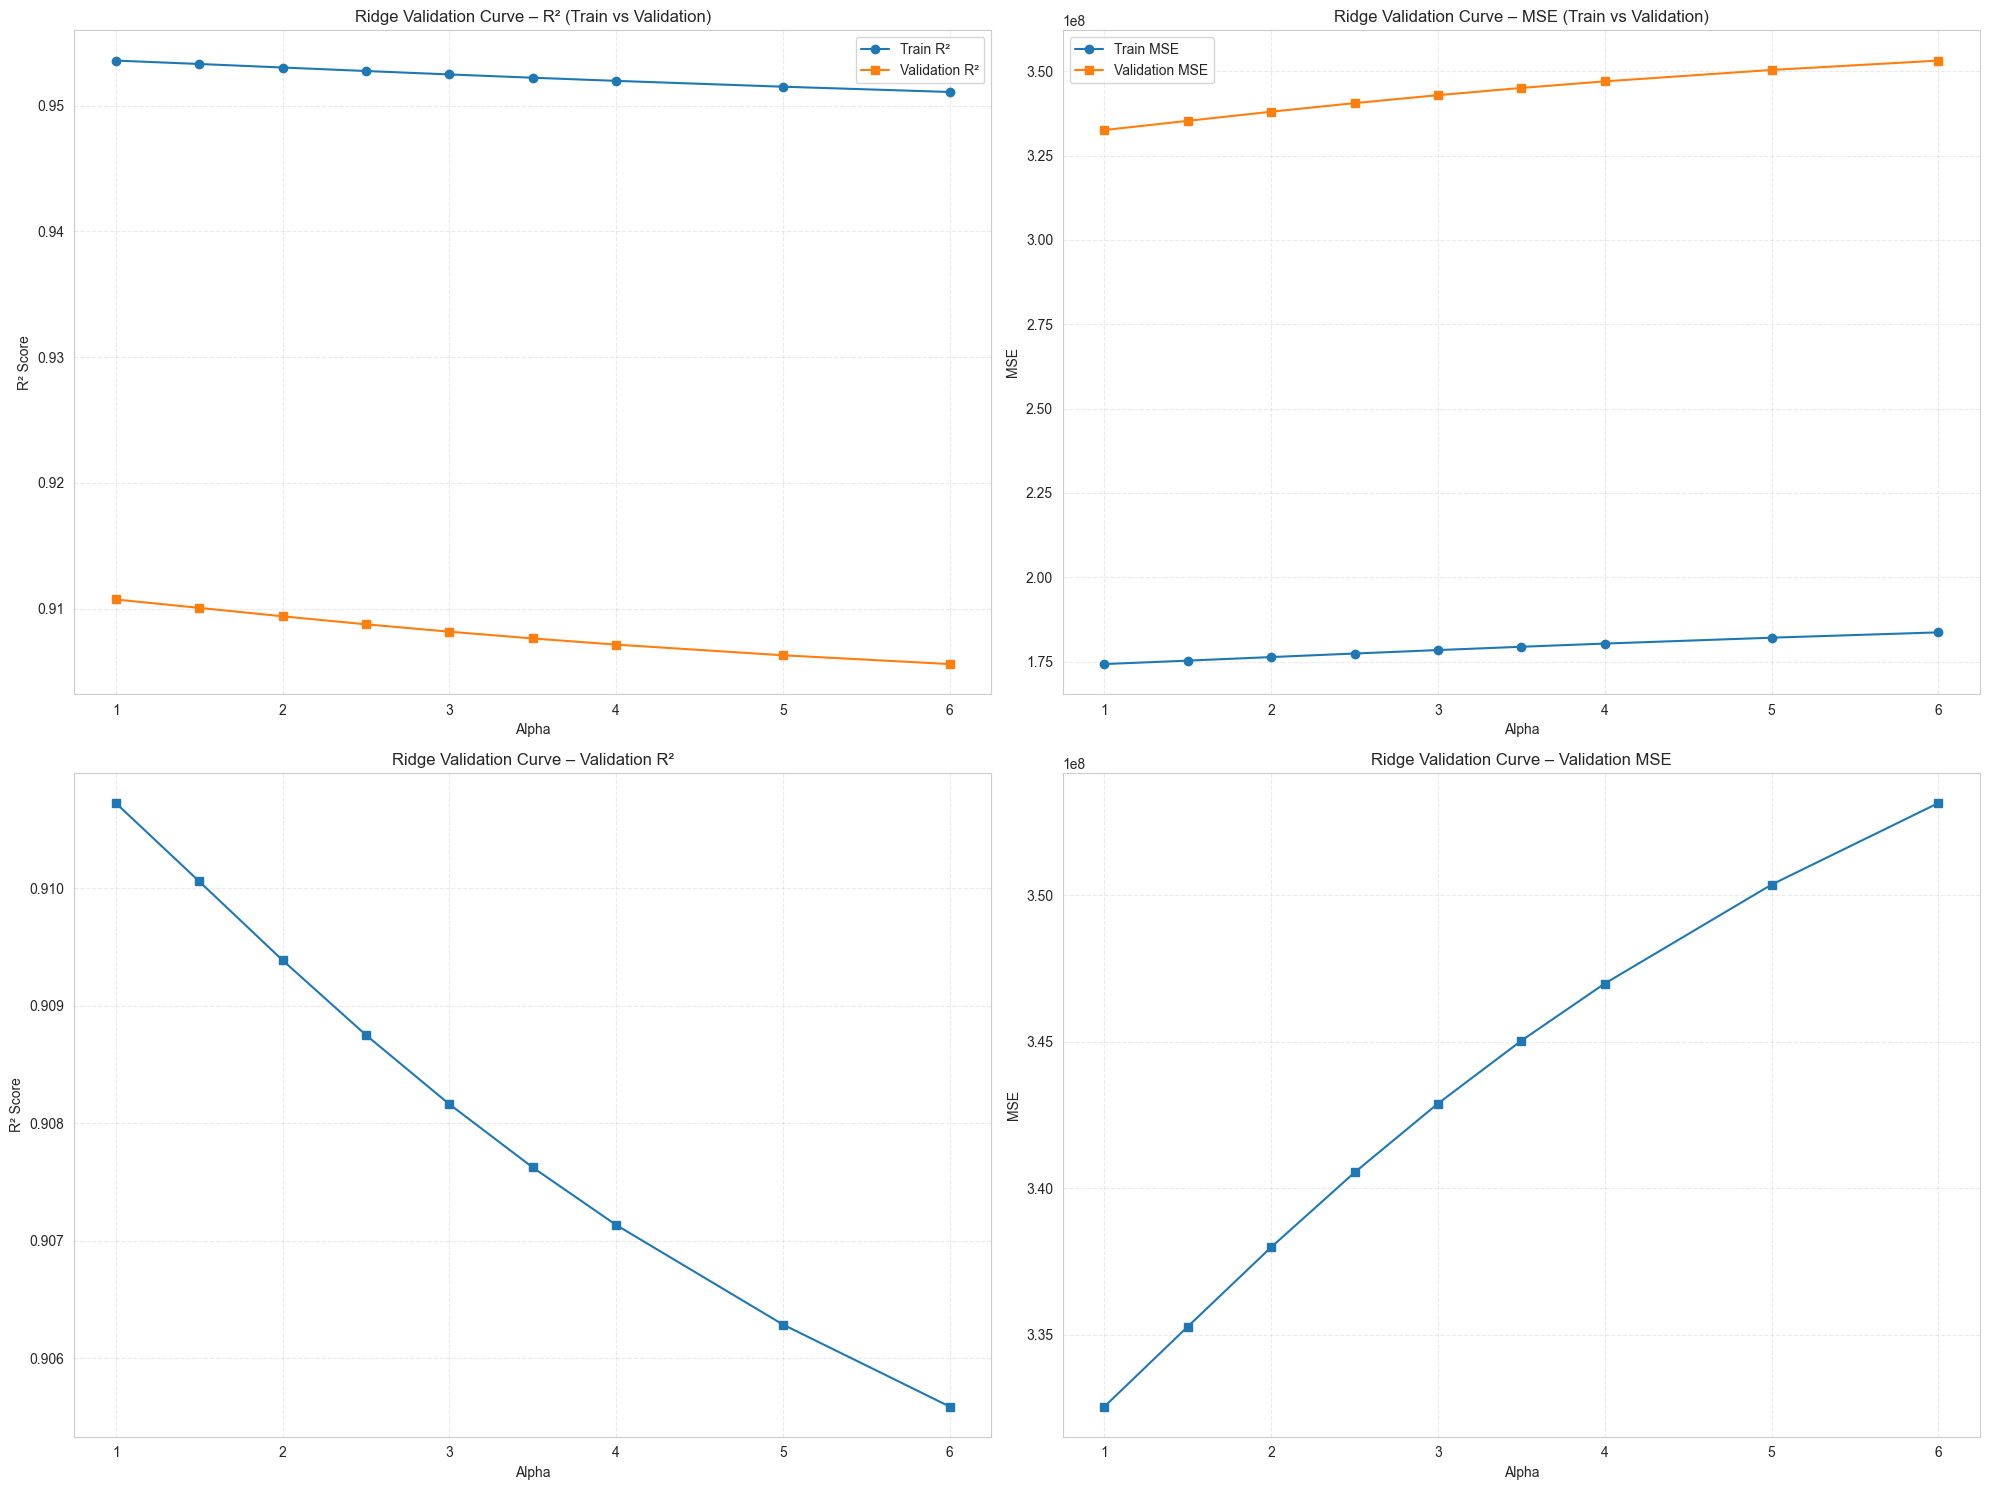

In [314]:
from sklearn.model_selection import validation_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Define model and alpha range
# -----------------------------
pipe = make_pipeline(
    StandardScaler(with_mean=False),
    PolynomialFeatures(degree=1, include_bias=False),  # best degree from tuning
    Ridge(random_state=42)
)

alpha_range = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0]

# -----------------------------
# 2) Validation curves (R² & MSE)
# -----------------------------
train_r2, test_r2 = validation_curve(
    estimator=pipe,
    X=X_train,
    y=y_train,
    param_name="ridge__alpha",
    param_range=alpha_range,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

train_mse, test_mse = validation_curve(
    estimator=pipe,
    X=X_train,
    y=y_train,
    param_name="ridge__alpha",
    param_range=alpha_range,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# convert negative MSE → positive MSE
train_mse = -train_mse
test_mse = -test_mse

# -----------------------------
# 3) PLOTS (same layout as example)
# -----------------------------
plt.figure(figsize=(20,15))

# --- (1) R² curve: Train vs Test ---
plt.subplot(2, 2, 1)
plt.plot(alpha_range, train_r2.mean(axis=1), label="Train R²", marker='o')
plt.plot(alpha_range, test_r2.mean(axis=1),  label="Validation R²", marker='s')
plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Ridge Validation Curve – R² (Train vs Validation)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# --- (2) MSE curve: Train vs Test ---
plt.subplot(2, 2, 2)
plt.plot(alpha_range, train_mse.mean(axis=1), label="Train MSE", marker='o')
plt.plot(alpha_range, test_mse.mean(axis=1),  label="Validation MSE", marker='s')
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Ridge Validation Curve – MSE (Train vs Validation)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

# --- (3) R² – Validation only ---
plt.subplot(2, 2, 3)
plt.plot(alpha_range, test_r2.mean(axis=1), marker='s')
plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Ridge Validation Curve – Validation R²")
plt.grid(True, linestyle='--', alpha=0.4)

# --- (4) MSE – Validation only ---
plt.subplot(2, 2, 4)
plt.plot(alpha_range, test_mse.mean(axis=1), marker='s')
plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Ridge Validation Curve – Validation MSE")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


The validation curves confirm that Ridge Regression behaves as expected for increasing regularization. As alpha increases from 1 to 6, both the training and validation R² scores decrease slightly, while the MSE increases. This indicates that stronger regularization makes the model simpler and slightly underfits. The curves show that smaller alpha values (around 1–2) give the best trade-off between bias and variance, which aligns with the earlier GridSearch result where α ≈ 2.07 produced the lowest RMSE. Overall, the validation curves validate the stability of the chosen Ridge model and illustrate how regularization affects model performance.

## Error analysis

In [315]:
# predictions on train and validation
y_train_pred = best_est.predict(X_train)
y_val_pred   = best_est.predict(X_val)

# residuals
train_residuals = y_train - y_train_pred
val_residuals   = y_val - y_val_pred

# absolute errors
train_abs = np.abs(train_residuals)
val_abs   = np.abs(val_residuals)

error_df = pd.DataFrame({
    "Actual": y_val,
    "Predicted": y_val_pred,
    "Residual": val_residuals,
    "AbsoluteError": val_abs
})

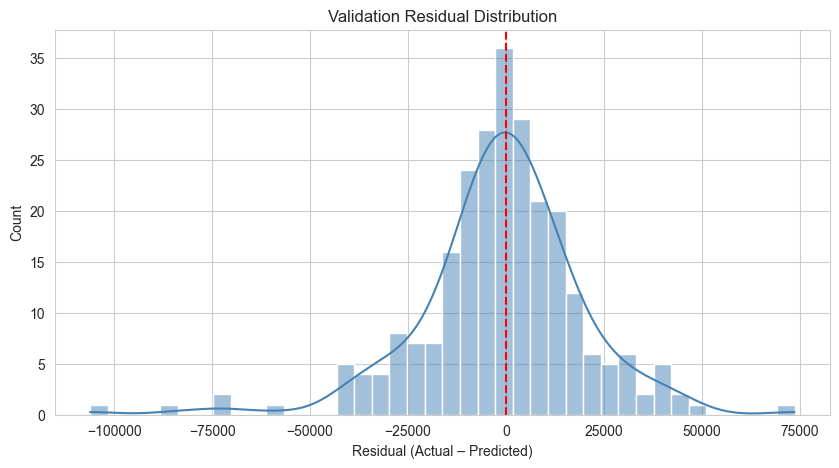

In [316]:
# Error Distribution
plt.figure(figsize=(10,5))
sns.histplot(val_residuals, kde=True, bins=40, color="steelblue")
plt.axvline(0, color="red", linestyle="--")
plt.title("Validation Residual Distribution")
plt.xlabel("Residual (Actual – Predicted)")
plt.show()

The residual distribution is centered tightly around zero, showing that the Ridge model does not exhibit systematic over- or under-prediction. The distribution is approximately normal with a few large negative and positive tails, which correspond to unusual or extreme houses in the validation set.

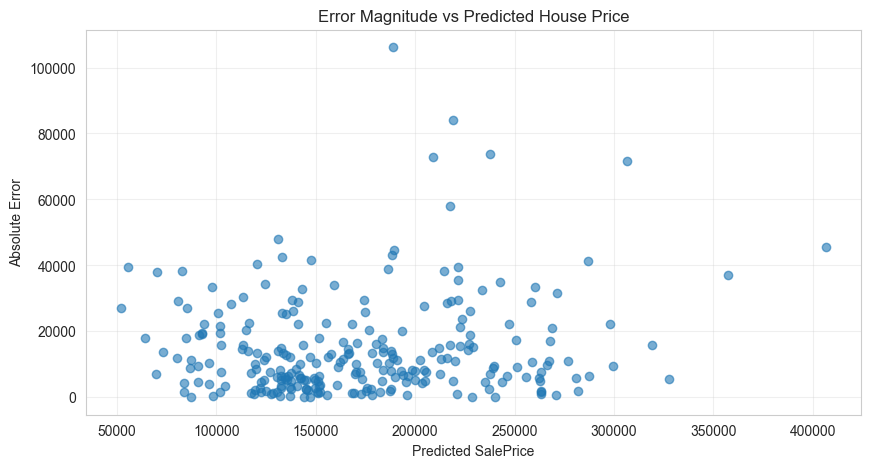

In [317]:
# Error vs Predicted Price
plt.figure(figsize=(10,5))
plt.scatter(y_val_pred, val_abs, alpha=0.6)
plt.xlabel("Predicted SalePrice")
plt.ylabel("Absolute Error")
plt.title("Error Magnitude vs Predicted House Price")
plt.grid(alpha=0.3)
plt.show()

The error-magnitude plot shows that most predictions fall within a reasonable error range, but errors increase for higher-priced homes. This is expected in the Ames dataset because luxury homes vary widely in features and are harder for linear models to capture.

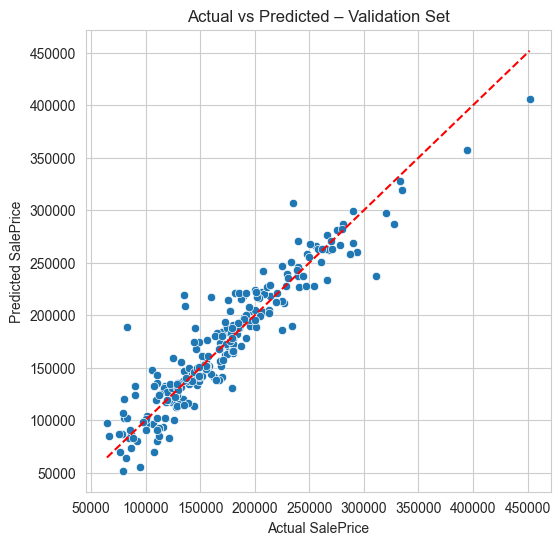

In [318]:
# Actual vs Predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_val, y=y_val_pred)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color="red", linestyle="--")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted – Validation Set")
plt.show()

The Actual vs Predicted plot shows that predictions align closely with the 45° line, indicating a strong linear fit. Most points lie near the line, with deviations primarily in the upper-price range, confirming the earlier observation that expensive properties contribute most to the error.

In [319]:
# Top 10 Worst Predictions
error_df_sorted = error_df.sort_values(by="AbsoluteError", ascending=False)
error_df_sorted.head(10)

,Actual,Predicted,Residual,AbsoluteError
552,82500.0,188649.496449,-106149.496449,106149.496449
548,135000.0,219056.699393,-84056.699393,84056.699393
192,311500.0,237863.870598,73636.129402,73636.129402
1201,136000.0,208998.729843,-72998.729843,72998.729843
221,235000.0,306526.613135,-71526.613135,71526.613135
624,159500.0,217443.786372,-57943.786372,57943.786372
643,179000.0,131118.331259,47881.668741,47881.668741
513,451950.0,406447.392576,45502.607424,45502.607424
486,234000.0,189324.994982,44675.005018,44675.005018
796,145000.0,188070.619545,-43070.619545,43070.619545


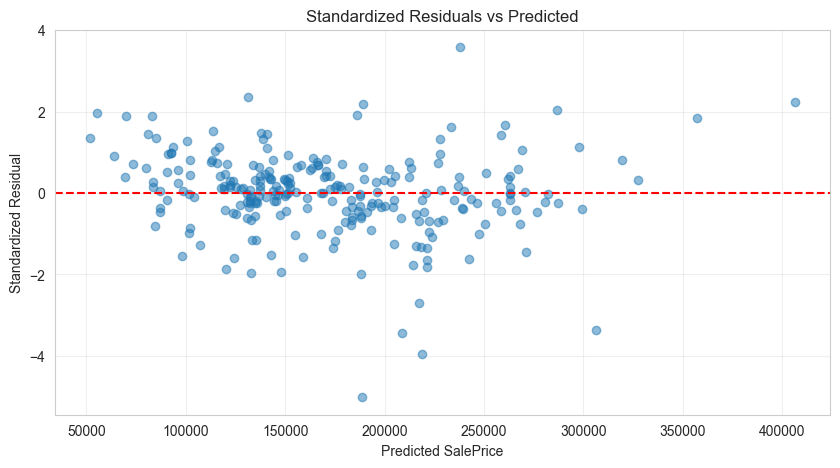

In [ ]:
# Standardized Residual Plot
std_resid = zscore(val_residuals)

plt.figure(figsize=(10,5))
plt.scatter(y_val_pred, std_resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted SalePrice")
plt.ylabel("Standardized Residual")
plt.title("Standardized Residuals vs Predicted")
plt.grid(alpha=0.3)
plt.show()

The standardized residuals show no clear pattern or funnel shape, meaning the model’s variance is stable across predicted prices and there is no major heteroscedasticity. The residuals appear randomly scattered, which is what we expect from a well-behaved linear model.

## SHAP and feature explainability

In [ ]:
best_alpha = 2.0691380811147897

best_model = make_pipeline(
    StandardScaler(with_mean=False),
    PolynomialFeatures(degree=1, include_bias=False),
    Ridge(alpha=best_alpha, random_state=42)
)

# fit model
best_model.fit(X_train, y_train)

X_train_trans = best_model.named_steps['standardscaler'].transform(X_train)
X_val_trans   = best_model.named_steps['standardscaler'].transform(X_val)

ridge_model = best_model.named_steps['ridge']

explainer = shap.LinearExplainer(
    ridge_model,
    X_train_trans,
    feature_perturbation="interventional"
)

# SHAP values
shap_values = explainer.shap_values(X_val_trans)

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


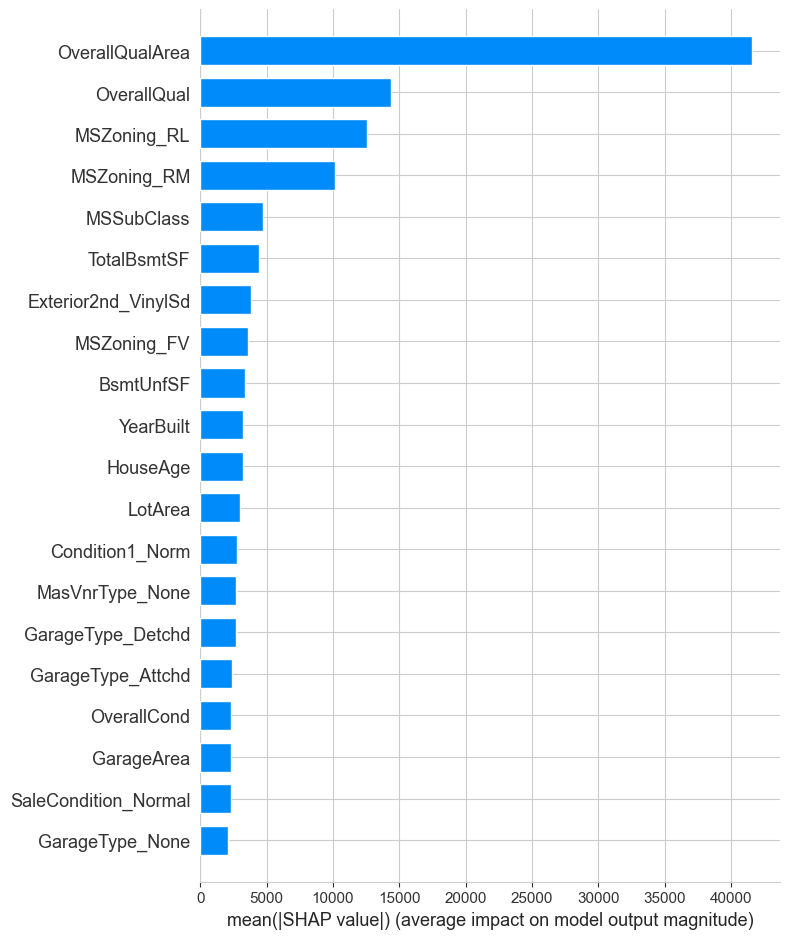

In [323]:
shap.summary_plot(
    shap_values,
    X_val,
    plot_type="bar",
    max_display=20
)

The SHAP bar plot shows the average absolute impact of each feature on prediction values. The most influential feature is OverallQualArea, which combines structural quality with total square footage, confirming that size and quality drive most variation in sale price. Other highly impactful features include OverallQual, TotalBsmtSF, YearBuilt, LotArea, and zoning-related categories such as MSZoning_RL.

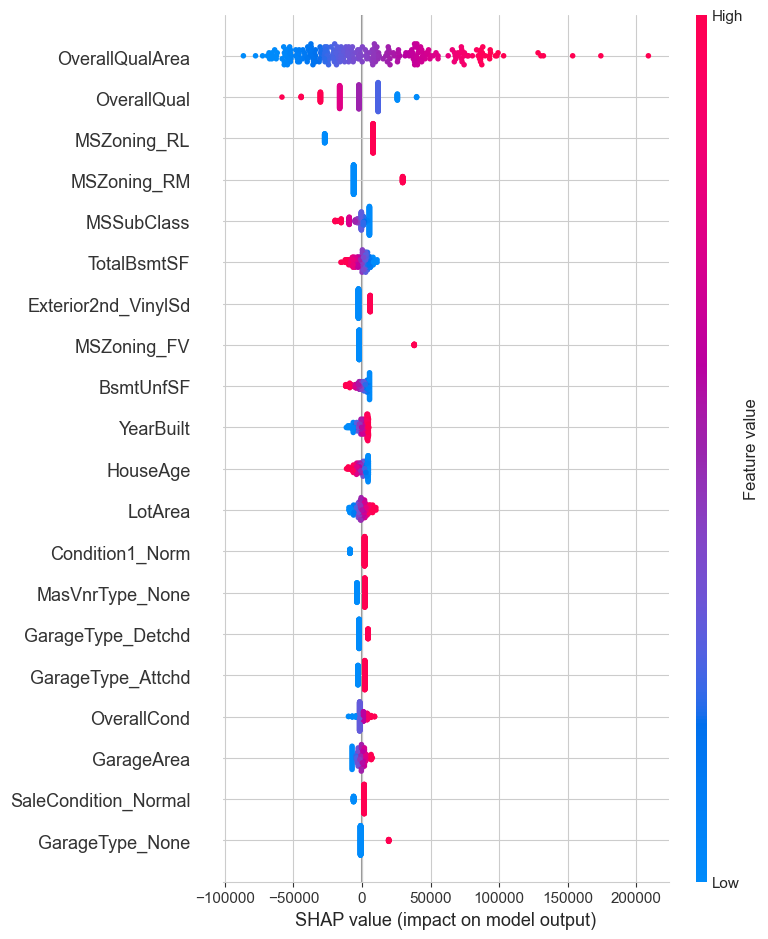

In [324]:
shap.summary_plot(
    shap_values,
    X_val,
    max_display=20
)

The SHAP beeswarm plot provides instance-level insight into how feature values affect individual predictions. High values (in red) for key features push predictions upward, while low values (in blue) push them downward. This indicates stable, monotonic relationships that align with the linear structure of the model. The spread of SHAP values also shows which features create the most variability across homes, with quality and area features dominating.

## Final Prediction & Submission

In [326]:
best_degree = gs.best_params_["polynomialfeatures__degree"]
best_alpha  = gs.best_params_["ridge__alpha"]

final_model = make_pipeline(
    StandardScaler(with_mean=False),
    PolynomialFeatures(degree=best_degree, include_bias=False),
    Ridge(alpha=best_alpha, random_state=42)
)

final_model.fit(X, y)
y_test_pred = final_model.predict(X_test)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y_test_pred
})

submission.to_csv("submission.csv", index=False)

In [ ]:
joblib.dump(final_model, "ridge_model.pkl")
print("Model saved as ridge_model.pkl")

# 2. Save the feature list in the correct order
feature_list = X.columns.tolist()      # X = full training features
joblib.dump(feature_list, "feature_list.pkl")
print("Feature list saved as feature_list.pkl")


Model saved as ridge_model.pkl
Feature list saved as feature_list.pkl
